# Model identification with PySINDy

STLSQ, FROLS and SSR fitted on the training levels (500, 1000, 2000 and 2500 mg) and tested on the 1500 mg level. Only the acceleration equation is identified (`x_dot = v` is imposed). The common training score selects the polynomial degree, the STLSQ threshold, the number of FROLS terms and the SSR parameters. Library columns are scaled to unit RMS, so the STLSQ threshold is a fraction of std($\dot v$). Admissible models need a restoring force, positive linear damping and the input term.

## Imports


In [1]:
import pickle
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pysindy as ps
from IPython.display import display
from sklearn.metrics import mean_squared_error, r2_score

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "notebooks" / "pipeline").is_dir():
    if PROJECT_ROOT == PROJECT_ROOT.parent:
        raise FileNotFoundError("Project root could not be located.")
    PROJECT_ROOT = PROJECT_ROOT.parent

COLORS = {"purple": "#5E3C99", "orange": "#D55E00", "green": "#009E73",
          "blue": "#0072B2", "brown": "#8C564B", "yellow": "#E69F00"}
plt.rcParams.update({
    "figure.figsize": (6, 4),
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
    "font.family": "serif",
    "font.size": 10,
    "mathtext.fontset": "stix",
    "axes.labelsize": 20,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 15,
    "lines.linewidth": 1.5,
    "axes.xmargin": 0.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "path.simplify": True,
    "agg.path.chunksize": 10000,
    "axes.prop_cycle": plt.cycler(color=list(COLORS.values())),
})


def slug(name):
    return re.sub(r"[^0-9a-zA-Z]+", "_", str(name)).strip("_").lower()

In [2]:
# Shared protocol: TEST_LEVEL_MG (both sweeps) is the test set; the other levels train.
# Predictions are made at the measured states; NRMSE = RMSE / std(measured).
LEVELS_MG = (500, 1000, 1500, 2000, 2500)
TEST_LEVEL_MG = 1500
TRAINING_LEVELS_MG = tuple(level for level in LEVELS_MG if level != TEST_LEVEL_MG)
ROLES = ("train", "test")
PROTOCOL_DESCRIPTION = (f"single train/test split: test level {TEST_LEVEL_MG} mg; "
                        f"training levels {TRAINING_LEVELS_MG} mg")
SWEEP_MIN_HZ, SWEEP_MAX_HZ = 50.0, 150.0
RESONANCE_BAND_HZ = (80.0, 110.0)
# Selection score on the training set: TOTAL_ERROR_WEIGHT * NRMSE
# + RESONANCE_ERROR_WEIGHT * resonance-band NRMSE. The smallest model within
# ACCEPTABLE_ERROR_INCREASE of the best score is selected.
TOTAL_ERROR_WEIGHT, RESONANCE_ERROR_WEIGHT = 0.3, 0.7
ACCEPTABLE_ERROR_INCREASE = 0.1


def excitation_level_mg(name):
    return int(re.search(r"(\d+)mg", str(name)).group(1))


def sweep_direction(name):
    return "down" if "sweep_down" in str(name) else "up"


def sweep_frequency_hz(name, t):
    """Nominal frequency, assuming a linear sweep."""
    fraction = (t - t[0]) / (t[-1] - t[0])
    if sweep_direction(name) == "down":
        return SWEEP_MAX_HZ - fraction * (SWEEP_MAX_HZ - SWEEP_MIN_HZ)
    return SWEEP_MIN_HZ + fraction * (SWEEP_MAX_HZ - SWEEP_MIN_HZ)


def resonance_band_mask(name, t):
    """Samples whose nominal sweep frequency lies in the resonance band."""
    frequency = sweep_frequency_hz(name, t)
    return (frequency >= RESONANCE_BAND_HZ[0]) & (frequency <= RESONANCE_BAND_HZ[1])


def signal_role(name):
    """Split role of an experiment: 'test' at the test level, 'train' otherwise."""
    return "test" if excitation_level_mg(name) == TEST_LEVEL_MG else "train"


def check_signals(signals, require_all_levels=True):
    names = [s["name"] for s in signals]
    if len(set(names)) != len(names):
        raise ValueError("Signal names must be unique.")
    found = {}
    for signal in signals:
        level = excitation_level_mg(signal["name"])
        if level not in LEVELS_MG:
            raise ValueError(f"Unknown excitation level: {signal['name']}")
        found.setdefault(level, []).append(sweep_direction(signal["name"]))
        arrays = [np.asarray(signal[k], dtype=float).reshape(-1) for k in ("t", "x", "v", "u", "v_dot")]
        if len({len(a) for a in arrays}) != 1 or len(arrays[0]) < 2:
            raise ValueError(f"Mismatched array lengths: {signal['name']}")
        if not all(np.isfinite(a).all() for a in arrays):
            raise ValueError(f"Nonfinite data: {signal['name']}")
        if np.any(np.diff(arrays[0]) <= 0):
            raise ValueError(f"Time must increase: {signal['name']}")
    for level in (LEVELS_MG if require_all_levels else found):
        if sorted(found.get(level, [])) != ["down", "up"]:
            raise ValueError(f"Level {level} mg needs exactly one upward and one downward sweep.")
    return sorted(signals, key=lambda s: (excitation_level_mg(s["name"]), s["name"]))


def split_signals(signals):
    """Single train/test split by excitation level."""
    signals = check_signals(signals)
    return {"test_level_mg": TEST_LEVEL_MG, "fit_levels_mg": TRAINING_LEVELS_MG,
            "fit": [s for s in signals if signal_role(s["name"]) == "train"],
            "test": [s for s in signals if signal_role(s["name"]) == "test"]}


def split_table(split):
    rows = []
    for role, key, levels in (("train", "fit", split["fit_levels_mg"]),
                              ("test", "test", (split["test_level_mg"],))):
        rows.append({"role": role, "levels_mg": tuple(levels), "experiments": len(split[key]),
                     "samples": sum(len(s["t"]) for s in split[key])})
    return pd.DataFrame(rows)


def scores(measured, predicted, resonance_mask, weights):
    residual = measured - predicted
    rmse = np.sqrt(np.mean(residual ** 2))
    nrmse = rmse / np.std(measured)
    r2 = 1.0 - np.sum(residual ** 2) / np.sum((measured - np.mean(measured)) ** 2)
    resonance = (np.sqrt(np.mean(residual[resonance_mask] ** 2))
                 / np.std(measured[resonance_mask]))
    return {"total_RMSE": rmse, "total_NRMSE": nrmse, "total_R2": r2,
            "resonance_NRMSE": resonance,
            "weighted_score": weights[0] * nrmse + weights[1] * resonance}


def build_series(signals):
    series = {}
    for signal in check_signals(signals, require_all_levels=False):
        name = signal["name"]
        t, x, v, u, measured = (np.asarray(signal[k], dtype=float).reshape(-1)
                                for k in ("t", "x", "v", "u", "v_dot"))
        series[name] = {
            "level_mg": excitation_level_mg(name), "sweep": sweep_direction(name),
            "role": signal_role(name),
            "time": t - t[0], "x": x, "v": v, "input": u,
            "experimental_acceleration": measured,
            "instantaneous_frequency_hz": sweep_frequency_hz(name, t),
            "resonance_mask": resonance_band_mask(name, t),
            "model_predictions": {},
        }
    return series


def add_predictions(series, model_functions, names=None):
    """Store each model's predictions under the role of each experiment (or only `names`)."""
    for name, record in series.items():
        if names is not None and name not in names:
            continue
        x, v, u = record["x"], record["v"], record["input"]
        for model_name, function in model_functions.items():
            predicted = np.broadcast_to(np.asarray(function(x, v, u), dtype=float),
                                        record["experimental_acceleration"].shape).astype(float)
            if not np.isfinite(predicted).all():
                raise ValueError(f"Nonfinite prediction: {model_name} on {name}")
            record["model_predictions"].setdefault(model_name, {})[record["role"]] = predicted
    return series


def summarize_models(series, weights=(TOTAL_ERROR_WEIGHT, RESONANCE_ERROR_WEIGHT)):
    """Metric tables per signal, per level and per role (train/test, pooled)."""
    per_signal, models = [], []
    for name, record in series.items():
        for model, roles in record["model_predictions"].items():
            if model not in models:
                models.append(model)
            for role, predicted in roles.items():
                per_signal.append({
                    "signal": name, "level_mg": record["level_mg"], "sweep": record["sweep"],
                    "model": model, "role": role,
                    **scores(record["experimental_acceleration"], predicted,
                             record["resonance_mask"], weights)})
    per_level, aggregate = [], []
    for model in models:
        names = [n for n, r in series.items() if model in r["model_predictions"]]

        def pooled(group):
            measured = np.concatenate([series[n]["experimental_acceleration"] for n in group])
            mask = np.concatenate([series[n]["resonance_mask"] for n in group])
            predicted = np.concatenate([series[n]["model_predictions"][model][series[n]["role"]]
                                        for n in group])
            return {"signals": len(group), "samples": len(measured),
                    **scores(measured, predicted, mask, weights)}

        for level in sorted({series[n]["level_mg"] for n in names}):
            group = [n for n in names if series[n]["level_mg"] == level]
            per_level.append({"level_mg": level, "role": series[group[0]]["role"],
                              "model": model, **pooled(group)})
        for role in ROLES:
            group = [n for n in names if series[n]["role"] == role]
            if group:
                aggregate.append({"model": model, "role": role,
                                  "levels_mg": tuple(sorted({series[n]["level_mg"] for n in group})),
                                  **pooled(group)})
    return (pd.DataFrame(per_signal), pd.DataFrame(per_level), pd.DataFrame(aggregate))


def regression_block(library, target, resonance_mask):
    """Library, target and resonance mask of one experiment (all samples)."""
    library = np.asarray(library, dtype=float)
    target = np.asarray(target, dtype=float).reshape(-1)
    resonance_mask = np.asarray(resonance_mask, dtype=bool).reshape(-1)
    if library.shape[0] != len(target) or len(resonance_mask) != len(target):
        raise ValueError("Library, target and resonance mask must have the same number of samples.")
    return {"Theta": library, "y": target, "resonance_mask": resonance_mask, "samples": len(target)}


def coefficient_scores(theta, blocks):
    """Pooled NRMSE, resonance-band NRMSE and selection score of a coefficient vector."""
    residual = np.concatenate([b["y"] - b["Theta"] @ theta for b in blocks])
    measured = np.concatenate([b["y"] for b in blocks])
    mask = np.concatenate([b["resonance_mask"] for b in blocks])
    total = np.sqrt(np.mean(residual ** 2)) / np.std(measured)
    resonance = np.sqrt(np.mean(residual[mask] ** 2)) / np.std(measured[mask])
    return {"nrmse": total, "resonance_nrmse": resonance,
            "score": TOTAL_ERROR_WEIGHT * total + RESONANCE_ERROR_WEIGHT * resonance}


def within_tolerance(results, score_column="training_score"):
    """Rows whose score is within ACCEPTABLE_ERROR_INCREASE of the best finite score."""
    finite = results[np.isfinite(results[score_column])]
    limit = finite[score_column].min() * (1.0 + ACCEPTABLE_ERROR_INCREASE) + 1e-14
    return finite[finite[score_column] <= limit]


In [3]:
# Line styles: solid = test, dashed = train.
ROLE_STYLES = {"train": "--", "test": "-"}
ROLE_LABELS = {"train": "Train", "test": "Test"}


def plot_diagnostics(series, folder):
    scales = {}
    folder = Path(folder)
    folder.mkdir(parents=True, exist_ok=True)
    for name, record in series.items():
        label = f"{record['level_mg']} mg, sweep {record['sweep']}"
        time, x, v, u = record["time"], record["x"], record["v"], record["input"]
        measured, mask = record["experimental_acceleration"], record["resonance_mask"]
        predictions = [(model, role, predicted)
                       for model, roles in record["model_predictions"].items()
                       for role, predicted in roles.items()]
        tip = measured + u
        x_scale, v_scale, tip_scale = (max(np.max(np.abs(a)), np.finfo(float).eps)
                                       for a in (x, v, tip))
        scales[name] = {"x_scale": x_scale, "v_scale": v_scale, "a_tip_scale": tip_scale,
                        "level_mg": record["level_mg"], "comparison_points": len(x),
                        "normalization": "maximum absolute experimental value"}

        for window, tag in [(slice(None), "time"), (mask, "resonance")]:
            fig, ax = plt.subplots()
            ax.plot(time[window], measured[window], color="k", lw=1.0,
                    label=f"Experimental - {label}")
            for model, role, predicted in predictions:
                ax.plot(time[window], predicted[window], ROLE_STYLES[role], lw=0.4,
                        alpha=0.55, label=f"{model} ({ROLE_LABELS[role]})")
            ax.set_xlabel("Time [s]")
            ax.set_ylabel("Relative acceleration [m/s$^2$]")
            ax.legend(loc="upper right")
            fig.savefig(folder / f"one_step_{tag}_{slug(name)}.pdf", format="pdf")
            plt.show()
            plt.close(fig)

        fig, ax = plt.subplots()
        for model, role, predicted in predictions:
            ax.scatter(measured, predicted, s=2, alpha=0.2, rasterized=True,
                       label=f"{model} ({ROLE_LABELS[role]})")
        limits = [float(measured.min()), float(measured.max())]
        ax.plot(limits, limits, "k--", lw=1.0, label=f"Ideal - {label}")
        ax.set_xlabel("Measured $a_{\\mathrm{rel}}$ [m/s$^2$]")
        ax.set_ylabel("Predicted $a_{\\mathrm{rel}}$ [m/s$^2$]")
        ax.legend(loc="upper left")
        fig.savefig(folder / f"one_step_parity_{slug(name)}.pdf", format="pdf")
        plt.show()
        plt.close(fig)

        cuts = [(v, v_scale, np.abs(x / x_scale) <= 1e-3, "velocity, $v^*$", "velocity"),
                (x, x_scale, np.abs(v / v_scale) <= 1e-3, "displacement, $x^*$", "displacement")]
        for axis, scale, cut, axis_label, tag in cuts:
            fig, ax = plt.subplots()
            ax.scatter(axis[cut] / scale, tip[cut] / tip_scale, s=9, color="k",
                       rasterized=True, label=f"Experimental - {label}")
            for model, role, predicted in predictions:
                ax.scatter(axis[cut] / scale, (predicted + u)[cut] / tip_scale, s=7,
                           alpha=0.5, rasterized=True, label=f"{model} ({ROLE_LABELS[role]})")
            ax.set_xlabel(f"Dimensionless {axis_label}")
            ax.set_ylabel("Dimensionless tip acceleration, $a_{\\mathrm{tip}}^*$")
            ax.legend(loc="upper left")
            fig.savefig(folder / f"dimensionless_{tag}_{slug(name)}.pdf", format="pdf")
            plt.show()
            plt.close(fig)
    return scales


def plot_level_metrics(per_level, metric, ylabel, filename):
    table = per_level.assign(label=per_level["model"] + " (" + per_level["role"].map(ROLE_LABELS) + ")")
    table = table.pivot(index="level_mg", columns="label", values=metric)
    fig, ax = plt.subplots()
    table.plot.bar(ax=ax)
    ax.set(xlabel="Excitation level [mg]", ylabel=ylabel)
    ax.tick_params(axis="x", rotation=0)
    ax.legend(fontsize=7)
    fig.savefig(filename)
    plt.show()
    plt.close(fig)
    return table

## Paths


In [4]:
RESULTS_DIR = PROJECT_ROOT / "results"
PREPARED_FILE = RESULTS_DIR / "prepared_signals.pkl"
FIGURES_DIR = PROJECT_ROOT / "figures" / "pipeline" / "3_pysindy"
if not PREPARED_FILE.exists():
    raise FileNotFoundError("results/prepared_signals.pkl was not found. Run notebook 2 first.")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


## Parameters

In [5]:
POLYNOMIAL_DEGREES = list(range(1, 11))
# STLSQ threshold as a fraction of the training std(v_dot). Columns are scaled to unit RMS,
# so terms whose RMS contribution is below the threshold are removed. 0 = least squares.
STLSQ_THRESHOLD_FRACTIONS = (0.0, 0.001, 0.002, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2)
STLSQ_ALPHA = 0.0001
STLSQ_MAX_ITER = 50
FROLS_MAX_TERMS = tuple(range(2, 21)) + (25, 30)
FROLS_ALPHA = 0.0001
SSR_MAX_ITER = 40
SSR_ALPHAS = (0.001, 0.01, 0.1)
SSR_CRITERION = "model_residual"


In [6]:
COEFFICIENT_TOLERANCE = 1e-12
# Selection weights and tolerance come from the shared protocol cell.


In [7]:
error_weight_sum = TOTAL_ERROR_WEIGHT + RESONANCE_ERROR_WEIGHT
if not np.isclose(error_weight_sum, 1.0):
    raise ValueError("The score weights must add up to 1.0.")


## Load signals and split


In [8]:
with open(PREPARED_FILE, "rb") as file:
    prepared_data = pickle.load(file)
spectral_signals = prepared_data["spectral_signals"]
print("File:", PREPARED_FILE)
print("Number of signals:", len(spectral_signals))
for index, signal in enumerate(spectral_signals):
    print(index, "-", signal["name"])


File: C:\Users\bruno\Downloads\BEPE (2)\BEPE\results\prepared_signals.pkl
Number of signals: 10
0 - relative_acceleration_000mA_1000mg_50-150_Hz_sweep-up-down__sweep_down
1 - relative_acceleration_000mA_1000mg_50-150_Hz_sweep-up-down__sweep_up
2 - relative_acceleration_000mA_1500mg_50-150_Hz_sweep-up-down__sweep_down
3 - relative_acceleration_000mA_1500mg_50-150_Hz_sweep-up-down__sweep_up
4 - relative_acceleration_000mA_2000mg_50-150_Hz_sweep-up-down__sweep_down
5 - relative_acceleration_000mA_2000mg_50-150_Hz_sweep-up-down__sweep_up
6 - relative_acceleration_000mA_2500mg_50-150_Hz_sweep-up-down__sweep_down
7 - relative_acceleration_000mA_2500mg_50-150_Hz_sweep-up-down__sweep_up
8 - relative_acceleration_000mA_500mg_50-150_Hz_sweep-up-down__sweep_down
9 - relative_acceleration_000mA_500mg_50-150_Hz_sweep-up-down__sweep_up


In [9]:
all_signals = check_signals(spectral_signals)
split = split_signals(all_signals)
split_summary = split_table(split)
display(split_summary)

,role,levels_mg,experiments,samples
0,train,"(500, 1000, 2000, 2500)",8,3211138
1,test,"(1500,)",2,802753


## Candidate library

No constant, input power at most one.


In [10]:
class LinearInputPolynomialLibrary(ps.PolynomialLibrary):

    @staticmethod
    def _combinations(n_features, degree, include_interaction, interaction_only, include_bias):
        combinations = ps.PolynomialLibrary._combinations(
            n_features=n_features,
            degree=degree,
            include_interaction=include_interaction,
            interaction_only=interaction_only,
            include_bias=include_bias,
        )
        input_index = n_features - 1
        return (combination for combination in combinations if combination.count(input_index) <= 1)


## Master library and regression rows of every experiment

Lower-degree libraries are prefixes of the master library, so one matrix per experiment serves every degree.

In [11]:
MASTER_DEGREE = max(POLYNOMIAL_DEGREES)
master_library = LinearInputPolynomialLibrary(degree=MASTER_DEGREE, include_bias=False)
master_library.fit(np.zeros((2, 3)))
FEATURE_NAMES = list(master_library.get_feature_names(["x", "v", "u"]))
POWERS = np.asarray(master_library.powers_, dtype=int)
TOTAL_DEGREE = POWERS.sum(axis=1)
for degree in POLYNOMIAL_DEGREES:
    library = LinearInputPolynomialLibrary(degree=degree, include_bias=False)
    library.fit(np.zeros((2, 3)))
    names = list(library.get_feature_names(["x", "v", "u"]))
    if names != FEATURE_NAMES[: len(names)] or int((TOTAL_DEGREE <= degree).sum()) != len(names):
        raise RuntimeError(f"Degree-{degree} library is not a prefix of the master library.")
print(f"Master library: degree {MASTER_DEGREE}, {len(FEATURE_NAMES)} features")


def degree_columns(degree):
    return np.flatnonzero(TOTAL_DEGREE <= degree)


def library_matrix(x, v, u):
    return np.asarray(master_library.transform(np.column_stack((x, v, u))), dtype=float)


def predict_acceleration(theta, x, v, u):
    active = np.flatnonzero(np.abs(theta) > COEFFICIENT_TOLERANCE)
    x, v, u = (np.asarray(a, dtype=float).reshape(-1) for a in (x, v, u))
    prediction = np.zeros_like(x)
    for column in active:
        px, pv, pu = POWERS[column]
        prediction += theta[column] * x**px * v**pv * u**pu
    return prediction


blocks = {}
for signal in all_signals:
    name = signal["name"]
    t, x, v, u, target = (np.asarray(signal[k], dtype=float).reshape(-1) for k in ("t", "x", "v", "u", "v_dot"))
    mask = resonance_band_mask(name, t)
    blocks[name] = {"name": name, "level_mg": excitation_level_mg(name), "role": signal_role(name),
                    **regression_block(library_matrix(x, v, u), target, mask)}
    print(f"{name} ({signal_role(name)}): {len(target):,} samples ({int(mask.sum()):,} in the resonance band), all used")

Master library: degree 10, 120 features
relative_acceleration_000mA_500mg_50-150_Hz_sweep-up-down__sweep_down (train): 401,408 samples (120,422 in the resonance band), all used
relative_acceleration_000mA_500mg_50-150_Hz_sweep-up-down__sweep_up (train): 401,408 samples (120,422 in the resonance band), all used
relative_acceleration_000mA_1000mg_50-150_Hz_sweep-up-down__sweep_down (train): 401,377 samples (120,413 in the resonance band), all used
relative_acceleration_000mA_1000mg_50-150_Hz_sweep-up-down__sweep_up (train): 401,376 samples (120,413 in the resonance band), all used
relative_acceleration_000mA_1500mg_50-150_Hz_sweep-up-down__sweep_down (test): 401,377 samples (120,413 in the resonance band), all used
relative_acceleration_000mA_1500mg_50-150_Hz_sweep-up-down__sweep_up (test): 401,376 samples (120,413 in the resonance band), all used
relative_acceleration_000mA_2000mg_50-150_Hz_sweep-up-down__sweep_down (train): 401,408 samples (120,422 in the resonance band), all used
rela

## Fitting and scoring on the full samples

In [12]:
def stacked_rows(signals, degree):
    columns = degree_columns(degree)
    Theta = np.vstack([blocks[s["name"]]["Theta"][:, columns] for s in signals])
    y = np.concatenate([blocks[s["name"]]["y"] for s in signals])
    return Theta, y, columns


def column_rms(signals, columns):
    """RMS of each library column over the stacked training samples."""
    squared = sum(np.sum(blocks[s["name"]]["Theta"][:, columns] ** 2, axis=0) for s in signals)
    n = sum(blocks[s["name"]]["samples"] for s in signals)
    rms = np.sqrt(squared / n)
    rms[rms == 0.0] = 1.0
    return rms


def target_std(signals):
    """Pooled standard deviation of the target over the training experiments."""
    return float(np.std(np.concatenate([blocks[s["name"]]["y"] for s in signals])))


def embed(values, columns):
    theta = np.zeros(len(FEATURE_NAMES))
    theta[columns] = values
    return theta


def fit_optimizer(make_optimizer, degree, signals):
    """Fit a PySINDy optimizer on the RMS-scaled training samples; return SI coefficients and history."""
    Theta, y, columns = stacked_rows(signals, degree)
    scale = column_rms(signals, columns)
    optimizer = make_optimizer(len(columns), target_std(signals))
    Theta /= scale  # in place, to avoid copying the training matrix
    optimizer.fit(Theta, y.reshape(-1, 1))
    theta = embed(np.asarray(optimizer.coef_, dtype=float)[0] / scale, columns)
    history = [embed(np.asarray(h, dtype=float)[0] / scale, columns)
               for h in getattr(optimizer, "history_", [])]
    return theta, history


def selection_score(theta, signals):
    """Pooled NRMSE, resonance-band NRMSE and common selection score on `signals`."""
    return coefficient_scores(theta, [blocks[s["name"]] for s in signals])


def count_active(theta):
    return int(np.count_nonzero(np.abs(theta) > COEFFICIENT_TOLERANCE))


def physical_diagnostics(theta):
    """Sign checks of the linear terms: restoring force (x < 0), damping (v < 0), input term."""
    terms = {tuple(int(p) for p in POWERS[i]): float(theta[i])
             for i in np.flatnonzero(np.abs(theta) > COEFFICIENT_TOLERANCE)}
    coefficient_x = terms.get((1, 0, 0), 0.0)
    coefficient_v = terms.get((0, 1, 0), 0.0)
    coefficient_u = terms.get((0, 0, 1), 0.0)
    restoring, damping = coefficient_x < 0.0, coefficient_v < 0.0
    input_term = abs(coefficient_u) > COEFFICIENT_TOLERANCE
    nonlinear = any(px + pv >= 2 for px, pv, _ in terms)
    return {
        "has_restoring_force": restoring, "has_damping": damping, "has_input_term": input_term,
        "has_state_nonlinearity": nonlinear,
        "physically_valid": restoring and damping and input_term,
        "linear_natural_frequency_hz": np.sqrt(-coefficient_x) / (2.0 * np.pi) if restoring else np.nan,
        "linear_damping_ratio": (-coefficient_v / (2.0 * np.sqrt(-coefficient_x)) if restoring and damping else np.nan),
    }


def equation_text(theta, precision=6):
    active = np.flatnonzero(np.abs(theta) > COEFFICIENT_TOLERANCE)
    return "v_dot = " + " + ".join(f"{theta[i]:.{precision}f} {FEATURE_NAMES[i]}" for i in active)


def active_polynomial_terms(theta):
    return [(float(theta[i]), *(int(p) for p in POWERS[i]))
            for i in np.flatnonzero(np.abs(theta) > COEFFICIENT_TOLERANCE)]


def make_stlsq(threshold_fraction):
    # Threshold = fraction * training std(v_dot), in the RMS-scaled problem.
    return lambda n, y_std: ps.STLSQ(threshold=threshold_fraction * y_std, alpha=STLSQ_ALPHA,
                                     max_iter=STLSQ_MAX_ITER, normalize_columns=False)


def make_frols(max_terms):
    # FROLS and SSR use PySINDy's own column normalization (overrides the RMS scaling).
    return lambda n, y_std: ps.FROLS(max_iter=min(max_terms, n), alpha=FROLS_ALPHA,
                                     normalize_columns=True, unbias=True, kappa=None, verbose=False)


def make_ssr(alpha):
    return lambda n, y_std: ps.SSR(max_iter=SSR_MAX_ITER, alpha=alpha, criteria=SSR_CRITERION,
                                   normalize_columns=True, unbias=True, kappa=None, verbose=False)


### Verification against a full PySINDy fit


In [13]:
VERIFICATION_DEGREE = 3
VERIFICATION_THRESHOLD_FRACTION = 0.02
verification_signals = split["fit"]

# 1. Least squares via fit_optimizer equals a full ps.SINDy fit.
reference = ps.SINDy(
    optimizer=ps.STLSQ(threshold=0.0, alpha=STLSQ_ALPHA, normalize_columns=True),
    feature_library=LinearInputPolynomialLibrary(degree=VERIFICATION_DEGREE, include_bias=False),
)
reference.fit(
    x=[np.column_stack((s["x"], s["v"])) for s in verification_signals],
    t=[np.asarray(s["t"], dtype=float) for s in verification_signals],
    x_dot=[np.column_stack((s["x_dot"], s["v_dot"])) for s in verification_signals],
    u=[np.asarray(s["u"], dtype=float).reshape(-1, 1) for s in verification_signals],
    feature_names=["x", "v", "u"],
)
reference_theta = embed(np.asarray(reference.optimizer.coef_, dtype=float)[1], degree_columns(VERIFICATION_DEGREE))
stacked_theta, _ = fit_optimizer(make_stlsq(0.0), VERIFICATION_DEGREE, verification_signals)
np.testing.assert_allclose(stacked_theta, reference_theta, rtol=1e-8, atol=1e-8 * np.max(np.abs(reference_theta)))
print("Least squares on the full samples (ps.SINDy):")
reference.print(lhs=["x_dot", "v_dot"], precision=6)
print("\nSame fit on the stacked samples (fit_optimizer):")
print(equation_text(stacked_theta))
del reference

# 2. STLSQ via fit_optimizer equals a direct STLSQ on the scaled matrix.
columns = degree_columns(VERIFICATION_DEGREE)
scale = column_rms(verification_signals, columns)
threshold = VERIFICATION_THRESHOLD_FRACTION * target_std(verification_signals)
Theta_full = np.vstack([library_matrix(s["x"], s["v"], s["u"])[:, columns] for s in verification_signals]) / scale
y_full = np.concatenate([np.asarray(s["v_dot"], dtype=float).reshape(-1) for s in verification_signals])
full_optimizer = ps.STLSQ(threshold=threshold, alpha=STLSQ_ALPHA, max_iter=STLSQ_MAX_ITER, normalize_columns=False)
full_optimizer.fit(Theta_full, y_full.reshape(-1, 1))
full_theta = embed(np.asarray(full_optimizer.coef_, dtype=float)[0] / scale, columns)
del Theta_full, y_full, full_optimizer
thresholded_theta, _ = fit_optimizer(make_stlsq(VERIFICATION_THRESHOLD_FRACTION), VERIFICATION_DEGREE, verification_signals)
np.testing.assert_allclose(thresholded_theta, full_theta, rtol=1e-8, atol=1e-8 * np.max(np.abs(full_theta)))
print(f"\nSTLSQ with threshold {VERIFICATION_THRESHOLD_FRACTION:g} std ({threshold:.4g} m/s^2): "
      f"{count_active(full_theta)} of {len(columns)} terms kept in the direct fit and through fit_optimizer.")
print(equation_text(thresholded_theta))
print("\nVerified: identical coefficients (rtol 1e-8).")


Least squares on the full samples (ps.SINDy):
x_dot =  1.000000 v
v_dot = -356581.321962 x + -27.115091 v + -1.058913 u +  15815479.984330 x^2 + -3324.127060 x v + -46.104279 x u + -41.019333 v^2 +  0.024947 v u +  20068037935.249737 x^3 + -4801672.414087 x^2 v +  62344.308454 x^2 u +  56752.033554 x v^2 +  125.087735 x v u + -28.599670 v^3 + -0.282039 v^2 u

Same fit on the stacked samples (fit_optimizer):
v_dot = -356581.321962 x + -27.115091 v + -1.058913 u + 15815479.984330 x^2 + -3324.127060 x v + -46.104279 x u + -41.019333 v^2 + 0.024947 v u + 20068037935.248947 x^3 + -4801672.414086 x^2 v + 62344.308454 x^2 u + 56752.033554 x v^2 + 125.087735 x v u + -28.599670 v^3 + -0.282039 v^2 u

STLSQ with threshold 0.02 std (1.288 m/s^2): 6 of 15 terms kept in the direct fit and through fit_optimizer.
v_dot = -353747.470599 x + -31.306880 v + -1.056662 u + 15372915.895446 x^2 + -43.652869 v^2 + 20587377023.465626 x^3

Verified: identical coefficients (rtol 1e-8).


## Selection on the training levels


In [14]:
def choose_sparsest(results, sort_keys, require_physical=True):
    """Smallest admissible model within the common tolerance of the best training score."""
    pool = results[results["physically_valid"]] if require_physical else results
    if pool.empty or not np.isfinite(pool["training_score"]).any():
        raise RuntimeError("No admissible model with a finite training score.")
    return within_tolerance(pool).sort_values(sort_keys).iloc[0]


def study_row(theta, parameters, fit_signals):
    fit_scores = selection_score(theta, fit_signals)
    return {**parameters, "training_nrmse": fit_scores["nrmse"],
            "training_resonance_nrmse": fit_scores["resonance_nrmse"], "training_score": fit_scores["score"],
            "active_terms": count_active(theta), **physical_diagnostics(theta)}


def run_identification(fit_signals, label):
    y_std = target_std(fit_signals)
    run = {"label": label, "fit_levels_mg": tuple(sorted({excitation_level_mg(s["name"]) for s in fit_signals})),
           "training_samples": sum(blocks[s["name"]]["samples"] for s in fit_signals), "target_std": y_std}

    # Polynomial degree: plain least squares (threshold 0) at every degree.
    rows, models = [], {}
    for degree in POLYNOMIAL_DEGREES:
        theta, _ = fit_optimizer(make_stlsq(0.0), degree, fit_signals)
        rows.append(study_row(theta, {"degree": degree}, fit_signals))
        models[degree] = theta
    degree_results = pd.DataFrame(rows)
    best_degree = int(choose_sparsest(degree_results, ["degree", "training_score"], require_physical=False)["degree"])
    run.update(degree_results=degree_results, best_degree=best_degree, least_squares=models[best_degree])

    # STLSQ: sparsity study over the threshold at the selected degree.
    rows, models = [], {}
    for fraction in STLSQ_THRESHOLD_FRACTIONS:
        theta, _ = fit_optimizer(make_stlsq(fraction), best_degree, fit_signals)
        rows.append(study_row(theta, {"threshold_fraction": fraction, "threshold_m_s2": fraction * y_std}, fit_signals))
        models[fraction] = theta
    stlsq_results = pd.DataFrame(rows)
    chosen = choose_sparsest(stlsq_results, ["active_terms", "training_score", "threshold_fraction"])
    run.update(stlsq_results=stlsq_results, stlsq_threshold_fraction=float(chosen["threshold_fraction"]),
               stlsq=models[float(chosen["threshold_fraction"])])

    # FROLS: number of terms.
    rows, models = [], {}
    for max_terms in FROLS_MAX_TERMS:
        if max_terms > len(degree_columns(best_degree)):
            continue
        theta, _ = fit_optimizer(make_frols(max_terms), best_degree, fit_signals)
        rows.append(study_row(theta, {"max_terms": max_terms, "alpha": FROLS_ALPHA}, fit_signals))
        models[max_terms] = theta
    frols_results = pd.DataFrame(rows)
    chosen = choose_sparsest(frols_results, ["active_terms", "training_score", "max_terms"])
    run.update(frols_results=frols_results, frols_max_terms=int(chosen["max_terms"]), frols=models[int(chosen["max_terms"])])

    # SSR: ridge parameter and history index. history_[0] is skipped: in PySINDy 2.1.0
    # it holds the final iterate, not the full model.
    rows, models = [], {}
    for alpha in SSR_ALPHAS:
        _, history = fit_optimizer(make_ssr(alpha), best_degree, fit_signals)
        for index, theta in enumerate(history):
            if index == 0 or count_active(theta) < 1:
                continue
            rows.append(study_row(theta, {"history_index": index, "alpha": alpha, "criteria": SSR_CRITERION}, fit_signals))
            models[alpha, index] = theta
    ssr_results = pd.DataFrame(rows).replace([np.inf, -np.inf], np.nan).dropna(subset=["training_score"])
    chosen = choose_sparsest(ssr_results, ["active_terms", "training_score", "alpha", "history_index"])
    run.update(ssr_results=ssr_results, ssr_alpha=float(chosen["alpha"]),
               ssr_history_index=int(chosen["history_index"]), ssr=models[float(chosen["alpha"]), int(chosen["history_index"])])
    run["models"] = {"STLSQ": run["stlsq"], "FROLS": run["frols"], "SSR": run["ssr"]}
    return run


identification_run = run_identification(split["fit"], f"training levels {split['fit_levels_mg']} mg")
print(f"Training levels {split['fit_levels_mg']} mg: degree {identification_run['best_degree']}, "
      f"STLSQ threshold {identification_run['stlsq_threshold_fraction']:g} std, "
      f"FROLS max_terms {identification_run['frols_max_terms']}, "
      f"SSR alpha {identification_run['ssr_alpha']:g} index {identification_run['ssr_history_index']}; active terms "
      + ", ".join(f"{k} {count_active(v)}" for k, v in identification_run["models"].items()))


Training levels (500, 1000, 2000, 2500) mg: degree 5, STLSQ threshold 0.005 std, FROLS max_terms 12, SSR alpha 0.001 index 24; active terms STLSQ 15, FROLS 12, SSR 11


### Selection summary


In [15]:
selection_summary = pd.DataFrame(
    [{"run": identification_run["label"], "fit_levels_mg": identification_run["fit_levels_mg"],
      "test_level_mg": split["test_level_mg"], "degree": identification_run["best_degree"],
      "stlsq_threshold_fraction": identification_run["stlsq_threshold_fraction"],
      "frols_max_terms": identification_run["frols_max_terms"], "ssr_alpha": identification_run["ssr_alpha"],
      "ssr_history_index": identification_run["ssr_history_index"],
      **{f"{m}_active_terms": count_active(theta) for m, theta in identification_run["models"].items()}}]
)
display(selection_summary)


,run,fit_levels_mg,test_level_mg,degree,stlsq_threshold_fraction,frols_max_terms,ssr_alpha,ssr_history_index,STLSQ_active_terms,FROLS_active_terms,SSR_active_terms
0,"training levels (500, 1000, 2000, 2500) mg","(500, 1000, 2000, 2500)",1500,5,0.005,12,0.001,24,15,12,11


## Selection studies on the training levels


,degree,training_nrmse,training_resonance_nrmse,training_score,active_terms,has_restoring_force,has_damping,has_input_term,has_state_nonlinearity,physically_valid,linear_natural_frequency_hz,linear_damping_ratio
0,1,0.048280,0.047254,0.047562,3,True,True,True,False,True,93.244945,0.026867
1,2,0.034430,0.030857,0.031929,8,True,True,True,True,True,93.261195,0.026763
2,3,0.019394,0.018262,0.018601,15,True,True,True,True,True,95.038468,0.022704
3,4,0.018962,0.017810,0.018156,24,True,True,True,True,True,95.058689,0.022744
4,5,0.014962,0.014492,0.014633,35,True,True,True,True,True,95.780927,0.021394
5,6,0.014845,0.014386,0.014523,48,True,True,True,True,True,95.791467,0.021343
6,7,0.014618,0.014315,0.014406,63,True,True,True,True,True,95.924933,0.020317
7,8,0.014560,0.014264,0.014353,80,True,True,True,True,True,95.933037,0.020276
8,9,0.014377,0.014165,0.014228,99,True,True,True,True,True,96.067204,0.019492
9,10,0.014319,0.014110,0.014173,120,True,True,True,True,True,96.085267,0.019471


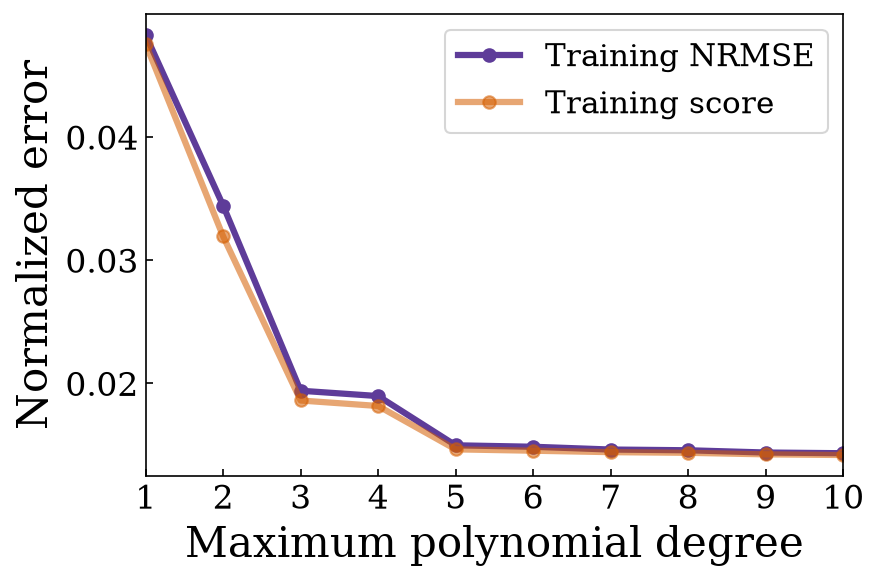

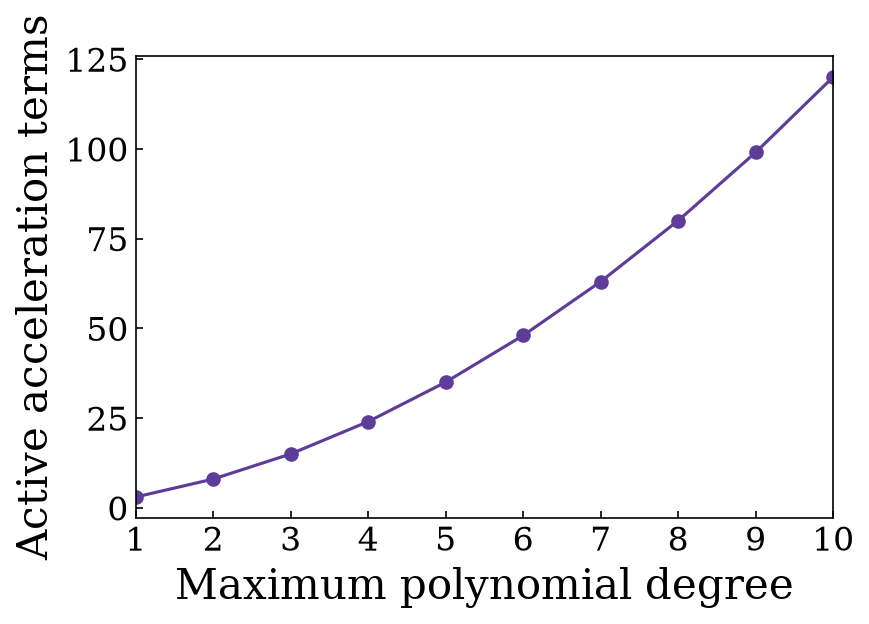

Selected polynomial degree: 5


In [16]:
degree_results = identification_run["degree_results"]
display(degree_results)
fig, ax = plt.subplots()
ax.plot(degree_results["degree"], degree_results["training_nrmse"], "o-", label="Training NRMSE", linewidth=3.0)
ax.plot(degree_results["degree"], degree_results["training_score"], "o-", label="Training score", alpha=0.55, linewidth=3.0)
ax.set_xticks(POLYNOMIAL_DEGREES)
ax.set_xlabel("Maximum polynomial degree")
ax.set_ylabel("Normalized error")
ax.legend()
fig.savefig(FIGURES_DIR / "degree_nrmse.pdf", format="pdf")
plt.show()
fig, ax = plt.subplots()
ax.plot(degree_results["degree"], degree_results["active_terms"], "o-")
ax.set_xticks(POLYNOMIAL_DEGREES)
ax.set_xlabel("Maximum polynomial degree")
ax.set_ylabel("Active acceleration terms")
fig.savefig(FIGURES_DIR / "degree_complexity.pdf", format="pdf")
plt.show()
BEST_DEGREE = identification_run["best_degree"]
print("Selected polynomial degree:", BEST_DEGREE)

,threshold_fraction,threshold_m_s2,training_nrmse,training_resonance_nrmse,training_score,active_terms,has_restoring_force,has_damping,has_input_term,has_state_nonlinearity,physically_valid,linear_natural_frequency_hz,linear_damping_ratio
0,0.000,0.000000,0.014962,0.014492,0.014633,35,True,True,True,True,True,95.780927,0.021394
1,0.001,0.064382,0.014968,0.014495,0.014637,30,True,True,True,True,True,95.781520,0.021393
2,0.002,0.128764,0.015358,0.014892,0.015032,17,True,True,True,True,True,95.748770,0.021753
3,0.005,0.321911,0.015598,0.015146,0.015282,15,True,True,True,True,True,95.759002,0.022036
4,0.010,0.643822,0.016776,0.015973,0.016214,10,True,True,True,True,True,95.758678,0.026123
5,0.020,1.287644,0.039176,0.040517,0.040115,5,True,True,True,True,True,95.429622,0.026277
6,0.050,3.219111,0.069747,0.069760,0.069756,2,True,False,True,False,False,93.304009,NaN
7,0.100,6.438222,0.069747,0.069760,0.069756,2,True,False,True,False,False,93.304009,NaN
8,0.200,12.876443,0.192510,0.110590,0.135166,1,True,False,False,False,False,94.051330,NaN


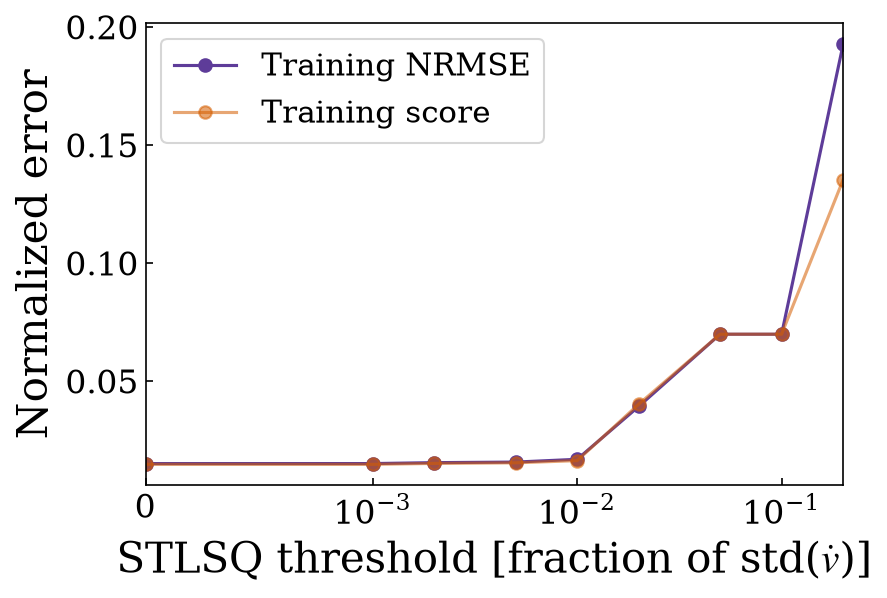

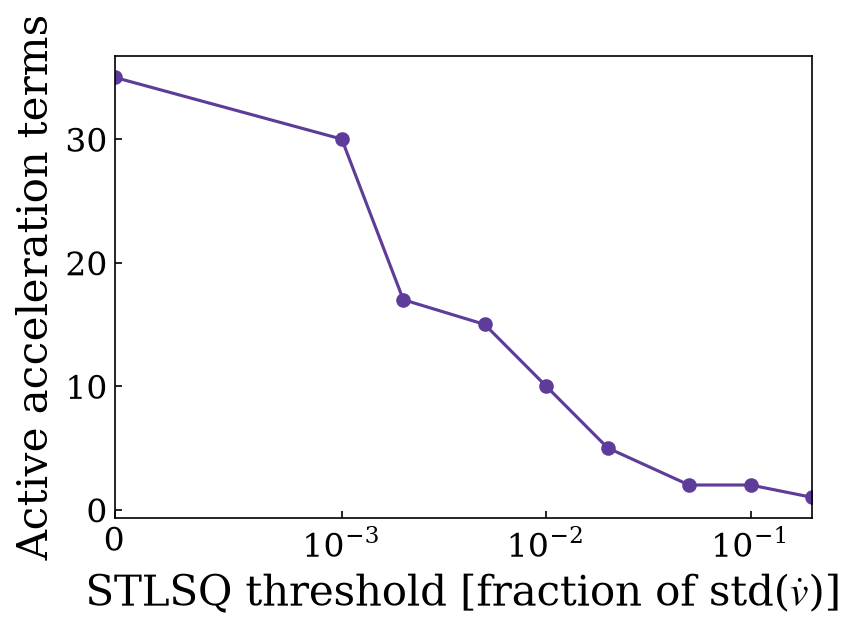

Selected STLSQ threshold fraction: 0.005


In [17]:
stlsq_results = identification_run["stlsq_results"]
display(stlsq_results)
linear_threshold = min(f for f in STLSQ_THRESHOLD_FRACTIONS if f > 0)
fig, ax = plt.subplots()
ax.plot(stlsq_results["threshold_fraction"], stlsq_results["training_nrmse"], "o-", label="Training NRMSE")
ax.plot(stlsq_results["threshold_fraction"], stlsq_results["training_score"], "o-", label="Training score", alpha=0.55)
ax.set_xscale("symlog", linthresh=linear_threshold)
ax.set_xlabel("STLSQ threshold [fraction of std($\\dot v$)]")
ax.set_ylabel("Normalized error")
ax.legend()
fig.savefig(FIGURES_DIR / "stlsq_threshold_nrmse.pdf", format="pdf")
plt.show()
fig, ax = plt.subplots()
ax.plot(stlsq_results["threshold_fraction"], stlsq_results["active_terms"], "o-")
ax.set_xscale("symlog", linthresh=linear_threshold)
ax.set_xlabel("STLSQ threshold [fraction of std($\\dot v$)]")
ax.set_ylabel("Active acceleration terms")
fig.savefig(FIGURES_DIR / "stlsq_threshold_complexity.pdf", format="pdf")
plt.show()
SELECTED_STLSQ_THRESHOLD_FRACTION = identification_run["stlsq_threshold_fraction"]
print("Selected STLSQ threshold fraction:", SELECTED_STLSQ_THRESHOLD_FRACTION)


,max_terms,alpha,training_nrmse,training_resonance_nrmse,training_score,active_terms,has_restoring_force,has_damping,has_input_term,has_state_nonlinearity,physically_valid,linear_natural_frequency_hz,linear_damping_ratio
0,2,0.0001,0.069747,0.069760,0.069756,2,True,False,True,False,False,93.304009,NaN
1,3,0.0001,0.048280,0.047254,0.047562,3,True,True,True,False,True,93.244945,0.026867
2,4,0.0001,0.048280,0.047254,0.047562,3,True,True,True,False,True,93.244945,0.026867
3,5,0.0001,0.048280,0.047254,0.047562,3,True,True,True,False,True,93.244945,0.026867
4,6,0.0001,0.024314,0.022917,0.023336,6,True,True,True,True,True,94.697258,0.026354
5,7,0.0001,0.021556,0.020472,0.020798,7,True,True,True,True,True,95.048507,0.026252
6,8,0.0001,0.020068,0.019399,0.019599,8,True,True,True,True,True,95.432651,0.026199
7,9,0.0001,0.019305,0.018767,0.018928,9,True,True,True,True,True,95.620028,0.026178
8,10,0.0001,0.019305,0.018767,0.018928,9,True,True,True,True,True,95.620028,0.026178
9,11,0.0001,0.016988,0.016118,0.016379,11,True,True,True,True,True,95.654308,0.026141


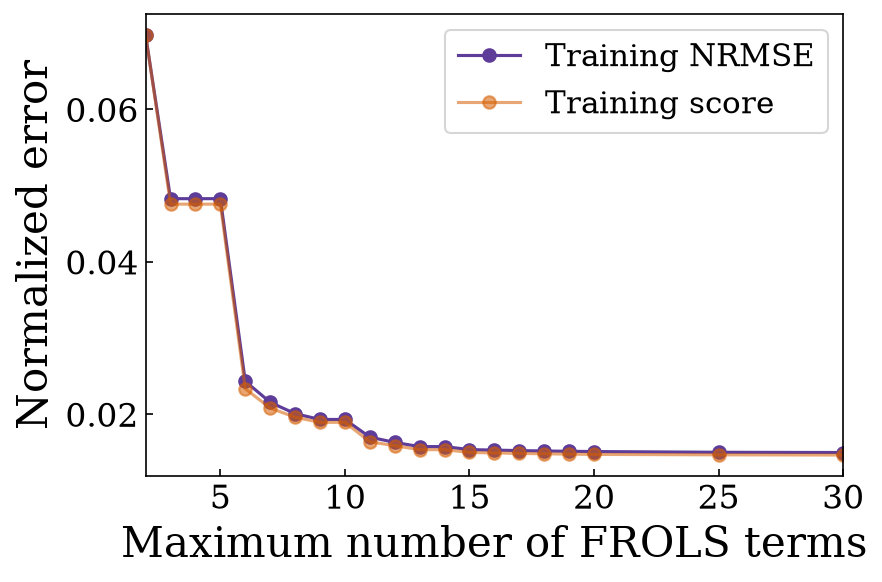

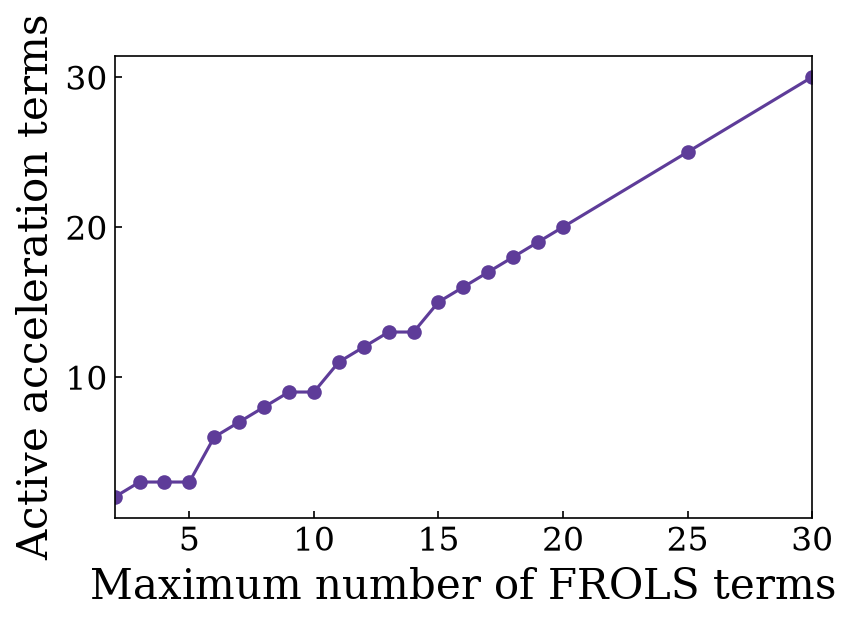

Selected FROLS maximum terms: 12


In [18]:
frols_results = identification_run["frols_results"]
display(frols_results)
fig, ax = plt.subplots()
ax.plot(frols_results["max_terms"], frols_results["training_nrmse"], "o-", label="Training NRMSE")
ax.plot(frols_results["max_terms"], frols_results["training_score"], "o-", label="Training score", alpha=0.55)
ax.set_xlabel("Maximum number of FROLS terms")
ax.set_ylabel("Normalized error")
ax.legend()
fig.savefig(FIGURES_DIR / "frols_nrmse.pdf", format="pdf")
plt.show()
fig, ax = plt.subplots()
ax.plot(frols_results["max_terms"], frols_results["active_terms"], "o-")
ax.set_xlabel("Maximum number of FROLS terms")
ax.set_ylabel("Active acceleration terms")
fig.savefig(FIGURES_DIR / "frols_complexity.pdf", format="pdf")
plt.show()
SELECTED_FROLS_MAX_TERMS = identification_run["frols_max_terms"]
print("Selected FROLS maximum terms:", SELECTED_FROLS_MAX_TERMS)

,history_index,alpha,criteria,training_nrmse,training_resonance_nrmse,training_score,active_terms,has_restoring_force,has_damping,has_input_term,has_state_nonlinearity,physically_valid,linear_natural_frequency_hz,linear_damping_ratio
0,1,0.001,model_residual,0.015229,0.014342,0.014608,34,True,True,True,True,True,95.502391,0.021462
1,2,0.001,model_residual,0.015229,0.014342,0.014608,33,True,True,True,True,True,95.502401,0.021461
2,3,0.001,model_residual,0.015230,0.014343,0.014609,32,True,True,True,True,True,95.502426,0.021462
3,4,0.001,model_residual,0.015231,0.014344,0.014610,31,True,True,True,True,True,95.502405,0.021462
4,5,0.001,model_residual,0.015232,0.014345,0.014611,30,True,True,True,True,True,95.502342,0.021456
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97,30,0.100,model_residual,0.095349,0.090072,0.091655,5,True,True,True,True,True,88.956005,0.023863
98,31,0.100,model_residual,0.099140,0.094642,0.095992,4,True,True,True,True,True,88.974931,0.023908
99,32,0.100,model_residual,0.101033,0.096838,0.098097,3,True,True,True,False,True,88.956402,0.023916
100,33,0.100,model_residual,0.112590,0.108593,0.109792,2,True,False,True,False,False,88.999800,NaN


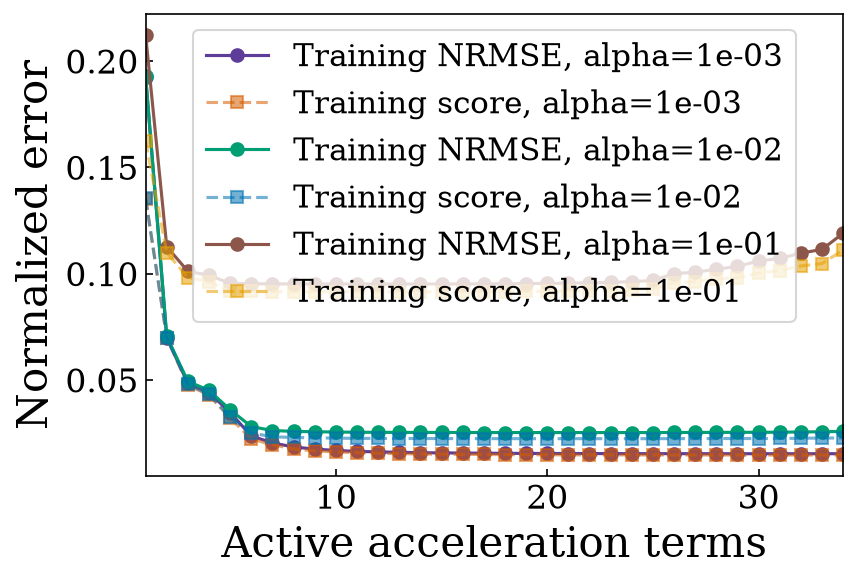

Selected SSR alpha / history index: 0.001 24


In [19]:
ssr_results = identification_run["ssr_results"]
display(ssr_results)
fig, ax = plt.subplots()
for alpha in SSR_ALPHAS:
    rows = ssr_results[np.isclose(ssr_results["alpha"], alpha)].sort_values("active_terms")
    ax.plot(rows["active_terms"], rows["training_nrmse"], "o-", label=f"Training NRMSE, alpha={alpha:.0e}")
    ax.plot(rows["active_terms"], rows["training_score"], "s--", alpha=0.55, label=f"Training score, alpha={alpha:.0e}")
ax.set_xlabel("Active acceleration terms")
ax.set_ylabel("Normalized error")
ax.legend()
fig.savefig(FIGURES_DIR / "ssr_nrmse.pdf", format="pdf")
plt.show()
SELECTED_SSR_ALPHA, SELECTED_SSR_HISTORY_INDEX = identification_run["ssr_alpha"], identification_run["ssr_history_index"]
print("Selected SSR alpha / history index:", SELECTED_SSR_ALPHA, SELECTED_SSR_HISTORY_INDEX)

## Selected models


In [20]:
final_models = identification_run["models"]
for model_name, theta in final_models.items():
    print("\n" + "=" * 70)
    print(model_name)
    print("=" * 70)
    print("x_dot = v   (imposed kinematic definition)")
    print(equation_text(theta))
    print("Active acceleration terms:", count_active(theta))
    display(pd.Series(physical_diagnostics(theta)))


STLSQ
x_dot = v   (imposed kinematic definition)
v_dot = -362008.657269 x + -26.516325 v + -1.057632 u + 13980702.509296 x^2 + -31.660765 v^2 + 50421822025.007256 x^3 + 148602.972890 x v^2 + -83.886199 v^3 + -1.216998 v^2 u + -36.661444 v^4 + -20636401961082564.000000 x^5 + -125110997901.265030 x^3 v^2 + -205153.454784 x v^4 + 165.148029 v^5 + 3.344961 v^4 u
Active acceleration terms: 15


has_restoring_force                 True
has_damping                         True
has_input_term                      True
has_state_nonlinearity              True
physically_valid                    True
linear_natural_frequency_hz    95.759002
linear_damping_ratio            0.022036
dtype: object


FROLS
x_dot = v   (imposed kinematic definition)
v_dot = -361214.575441 x + -28.067892 v + -1.060837 u + 11996851.349633 x^2 + -30.939004 v^2 + 51585666101.215141 x^3 + 71407.422790 x v^2 + -19.878265 v^3 + 2263613572695.190918 x^4 + -33.140505 v^4 + -21574075476601784.000000 x^5 + -86425053592.525864 x^3 v^2
Active acceleration terms: 12


has_restoring_force                 True
has_damping                         True
has_input_term                      True
has_state_nonlinearity              True
physically_valid                    True
linear_natural_frequency_hz    95.653918
linear_damping_ratio            0.023351
dtype: object


SSR
x_dot = v   (imposed kinematic definition)
v_dot = -359969.007386 x + -28.028689 v + -1.060579 u + 14684561.282339 x^2 + -42.685047 v^2 + 43782180387.402817 x^3 + 115740.667383 x v^2 + -19.781429 v^3 + -16704710901140226.000000 x^5 + -96307268048.607666 x^3 v^2 + -135255.143357 x v^4
Active acceleration terms: 11


has_restoring_force                 True
has_damping                         True
has_input_term                      True
has_state_nonlinearity              True
physically_valid                    True
linear_natural_frequency_hz    95.488855
linear_damping_ratio            0.023358
dtype: object

### Note

STLSQ, FROLS and SSR are all passed to the comparison notebook.

## One-step results


,signal,level_mg,sweep,model,role,total_RMSE,total_NRMSE,total_R2,resonance_NRMSE,weighted_score
0,relative_acceleration_000mA_500mg_50-150_Hz_sw...,500,down,STLSQ,train,0.318436,0.014797,0.999781,0.012738,0.013356
1,relative_acceleration_000mA_500mg_50-150_Hz_sw...,500,down,FROLS,train,0.328738,0.015276,0.999767,0.012797,0.013541
2,relative_acceleration_000mA_500mg_50-150_Hz_sw...,500,down,SSR,train,0.343204,0.015948,0.999746,0.013165,0.014000
3,relative_acceleration_000mA_500mg_50-150_Hz_sw...,500,up,STLSQ,train,0.298052,0.014346,0.999794,0.012197,0.012842
4,relative_acceleration_000mA_500mg_50-150_Hz_sw...,500,up,FROLS,train,0.313041,0.015068,0.999773,0.012491,0.013264
5,relative_acceleration_000mA_500mg_50-150_Hz_sw...,500,up,SSR,train,0.336120,0.016179,0.999738,0.013411,0.014241
6,relative_acceleration_000mA_1000mg_50-150_Hz_s...,1000,down,STLSQ,train,0.781632,0.019601,0.999616,0.019985,0.019870
7,relative_acceleration_000mA_1000mg_50-150_Hz_s...,1000,down,FROLS,train,0.816594,0.020478,0.999581,0.020804,0.020706
8,relative_acceleration_000mA_1000mg_50-150_Hz_s...,1000,down,SSR,train,0.747368,0.018742,0.999649,0.018809,0.018789
9,relative_acceleration_000mA_1000mg_50-150_Hz_s...,1000,up,STLSQ,train,0.773714,0.020181,0.999593,0.020848,0.020648


,level_mg,role,model,signals,samples,total_RMSE,total_NRMSE,total_R2,resonance_NRMSE,weighted_score
0,500,train,STLSQ,2,802816,0.308412,0.014581,0.999787,0.012481,0.013111
1,1000,train,STLSQ,2,802753,0.777683,0.019881,0.999605,0.020403,0.020247
2,1500,test,STLSQ,2,802753,1.025530,0.017481,0.999694,0.017495,0.017491
3,2000,train,STLSQ,2,802816,1.133941,0.014894,0.999778,0.014891,0.014892
4,2500,train,STLSQ,2,802753,1.431263,0.015252,0.999767,0.014330,0.014607
5,500,train,FROLS,2,802816,0.320985,0.015176,0.999770,0.012650,0.013408
6,1000,train,FROLS,2,802753,0.803563,0.020543,0.999578,0.020987,0.020854
7,1500,test,FROLS,2,802753,1.109944,0.018920,0.999642,0.018907,0.018911
8,2000,train,FROLS,2,802816,1.210884,0.015904,0.999747,0.015873,0.015883
9,2500,train,FROLS,2,802753,1.479040,0.015761,0.999752,0.014568,0.014926


,model,role,levels_mg,signals,samples,total_RMSE,total_NRMSE,total_R2,resonance_NRMSE,weighted_score
0,STLSQ,train,"(500, 1000, 2000, 2500)",8,3211138,1.004265,0.015598,0.999757,0.015146,0.015282
1,STLSQ,test,"(1500,)",2,802753,1.025530,0.017481,0.999694,0.017495,0.017491
2,FROLS,train,"(500, 1000, 2000, 2500)",8,3211138,1.049106,0.016295,0.999734,0.015685,0.015868
3,FROLS,test,"(1500,)",2,802753,1.109944,0.018920,0.999642,0.018907,0.018911
4,SSR,train,"(500, 1000, 2000, 2500)",8,3211138,1.050641,0.016319,0.999734,0.015407,0.015681
5,SSR,test,"(1500,)",2,802753,1.018124,0.017355,0.999699,0.017076,0.017159


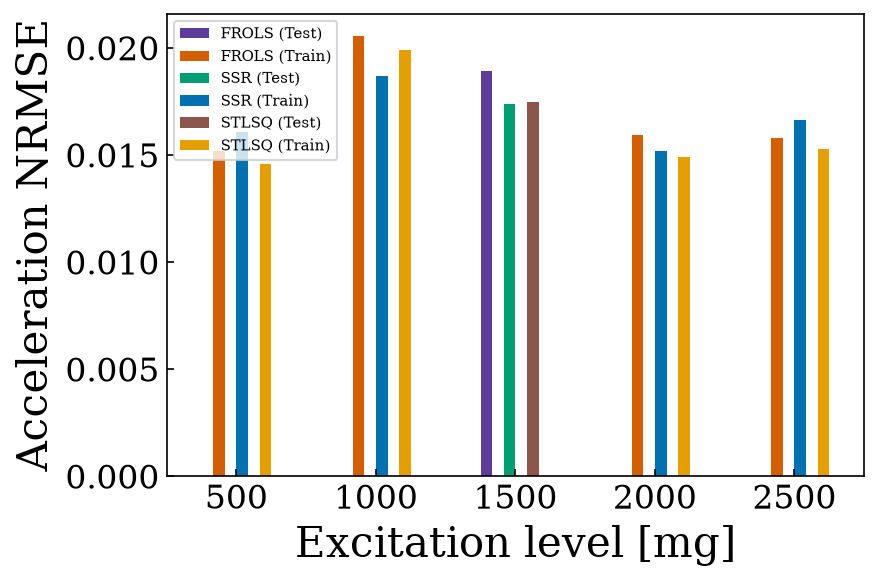

label,FROLS (Test),FROLS (Train),SSR (Test),SSR (Train),STLSQ (Test),STLSQ (Train)
level_mg,,,,,,
500,NaN,0.015176,NaN,0.016060,NaN,0.014581
1000,NaN,0.020543,NaN,0.018688,NaN,0.019881
1500,0.01892,NaN,0.017355,NaN,0.017481,NaN
2000,NaN,0.015904,NaN,0.015186,NaN,0.014894
2500,NaN,0.015761,NaN,0.016608,NaN,0.015252


In [21]:
one_step_series = build_series(all_signals)
add_predictions(one_step_series,
                {name: (lambda x, v, u, theta=theta: predict_acceleration(theta, x, v, u))
                 for name, theta in final_models.items()})
one_step_comparison, one_step_per_level, one_step_aggregate = summarize_models(one_step_series)
display(one_step_comparison)
display(one_step_per_level)
display(one_step_aggregate)
plot_level_metrics(one_step_per_level, "total_NRMSE", "Acceleration NRMSE", FIGURES_DIR / "one_step_level_metrics.pdf")

## Dimensionless diagnostics


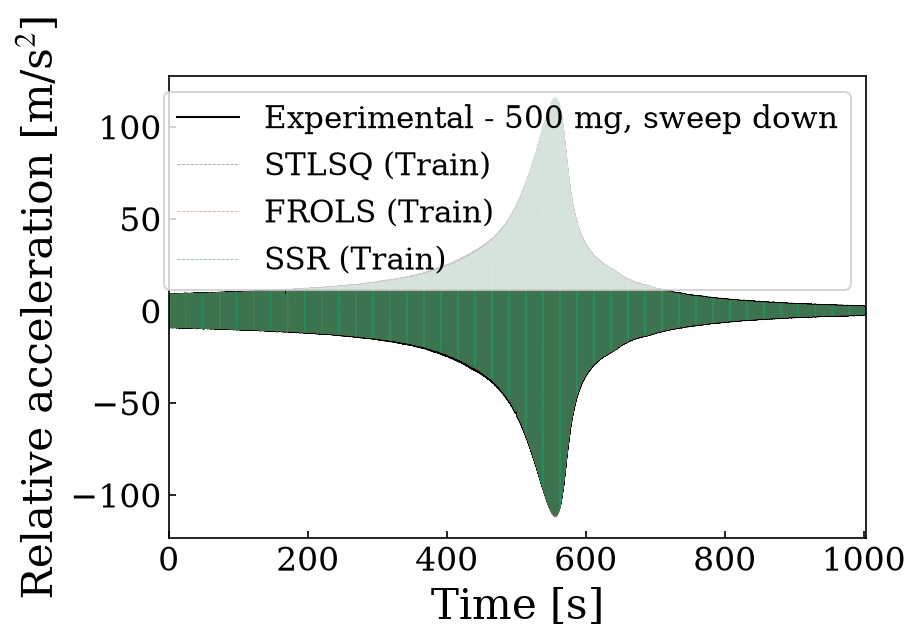

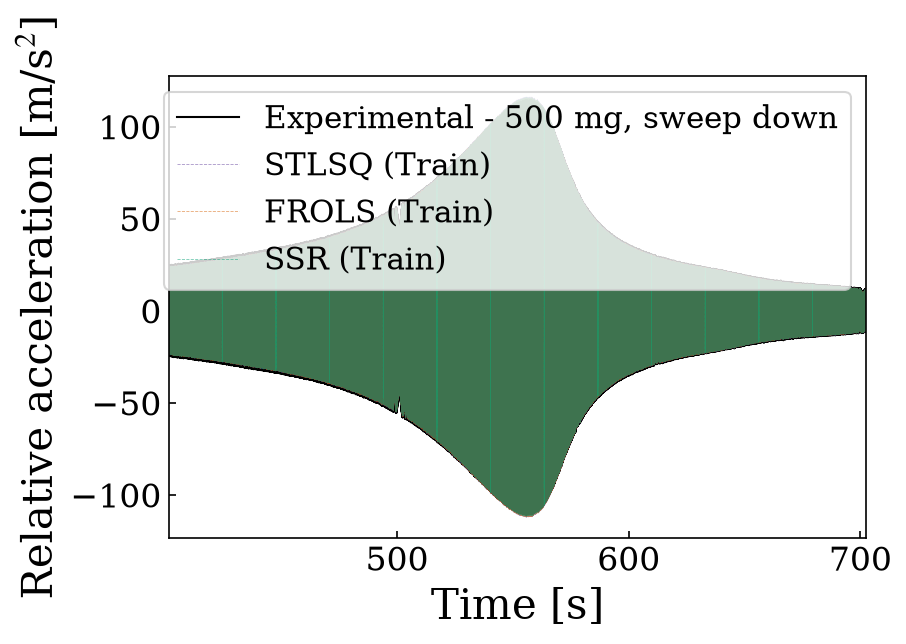

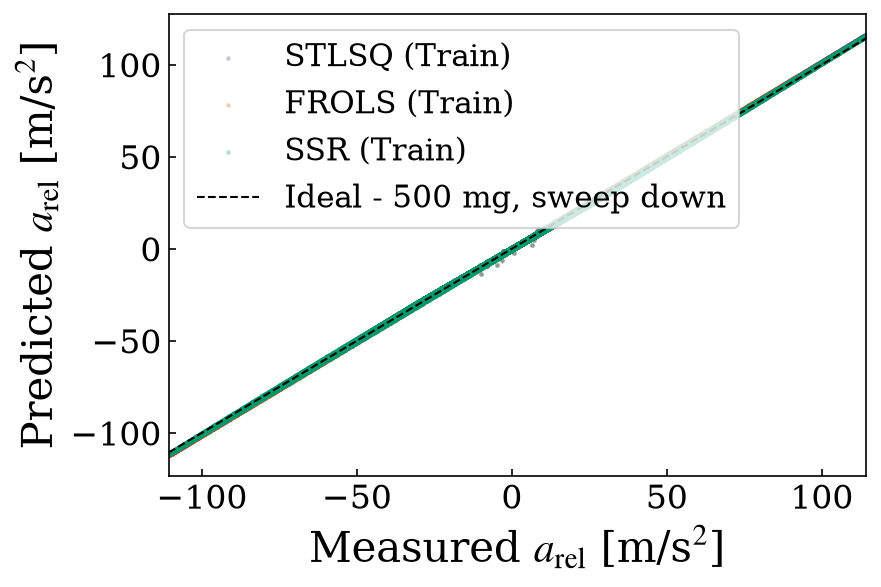

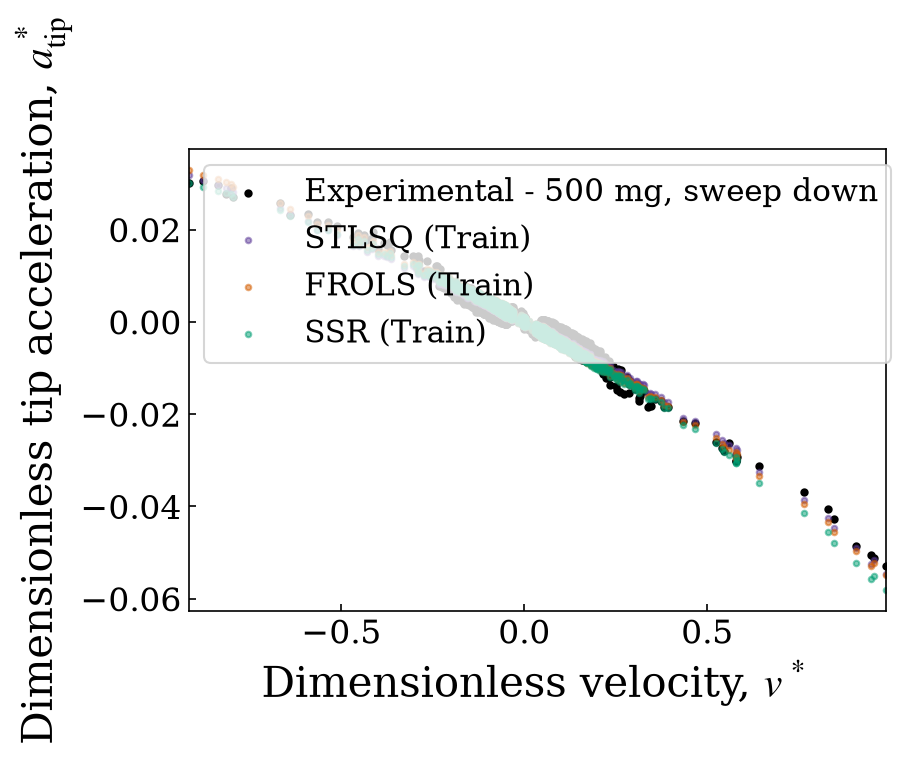

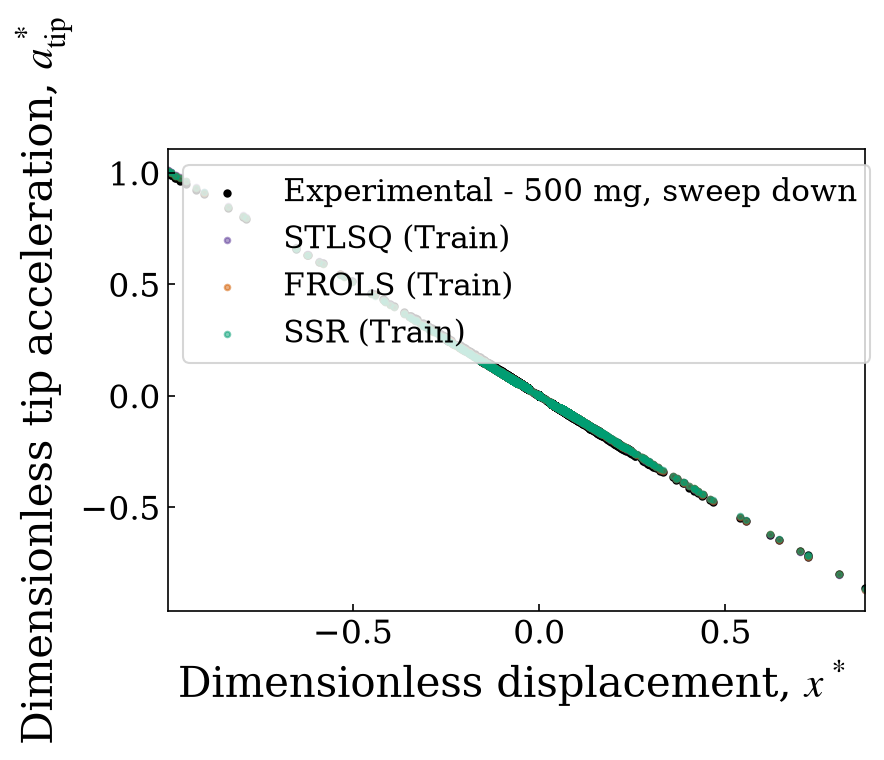

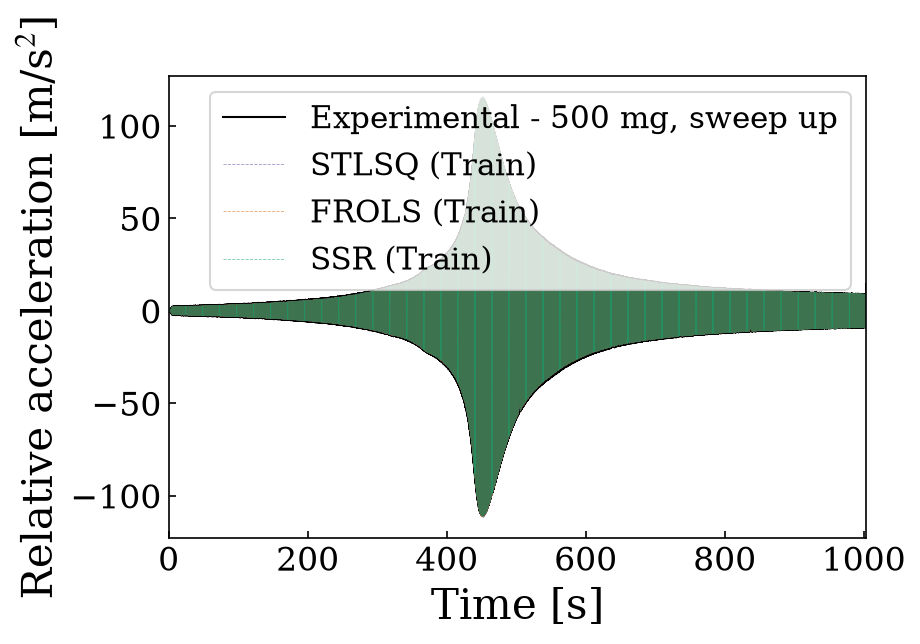

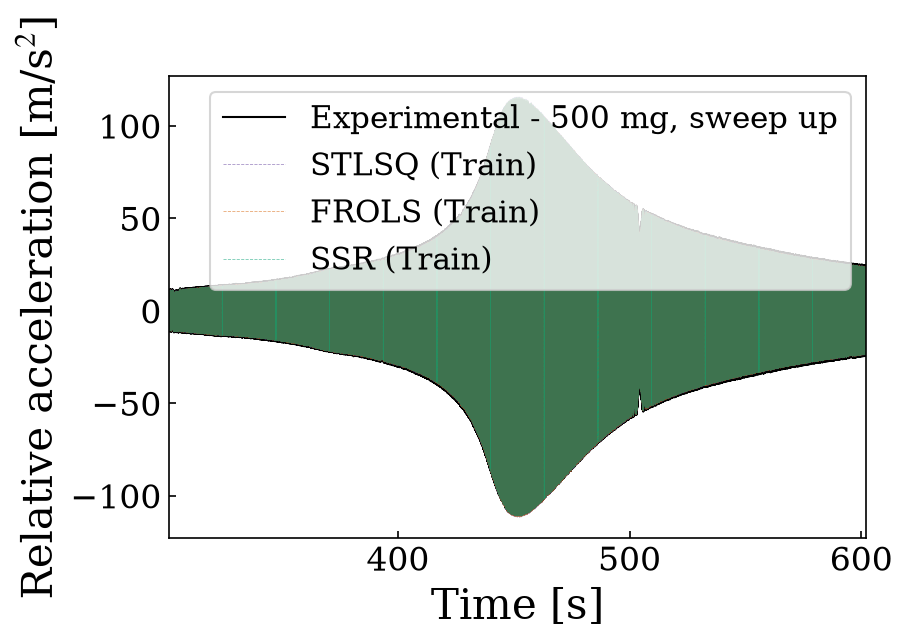

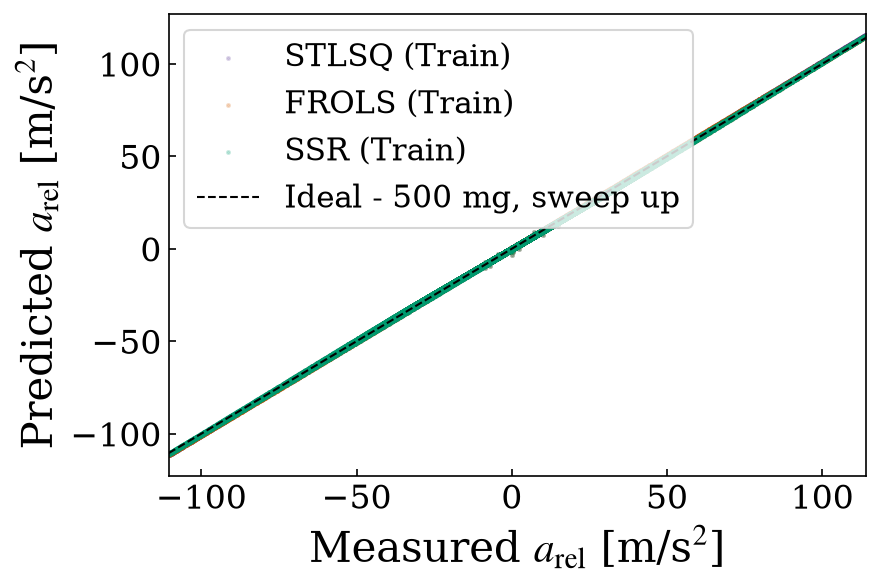

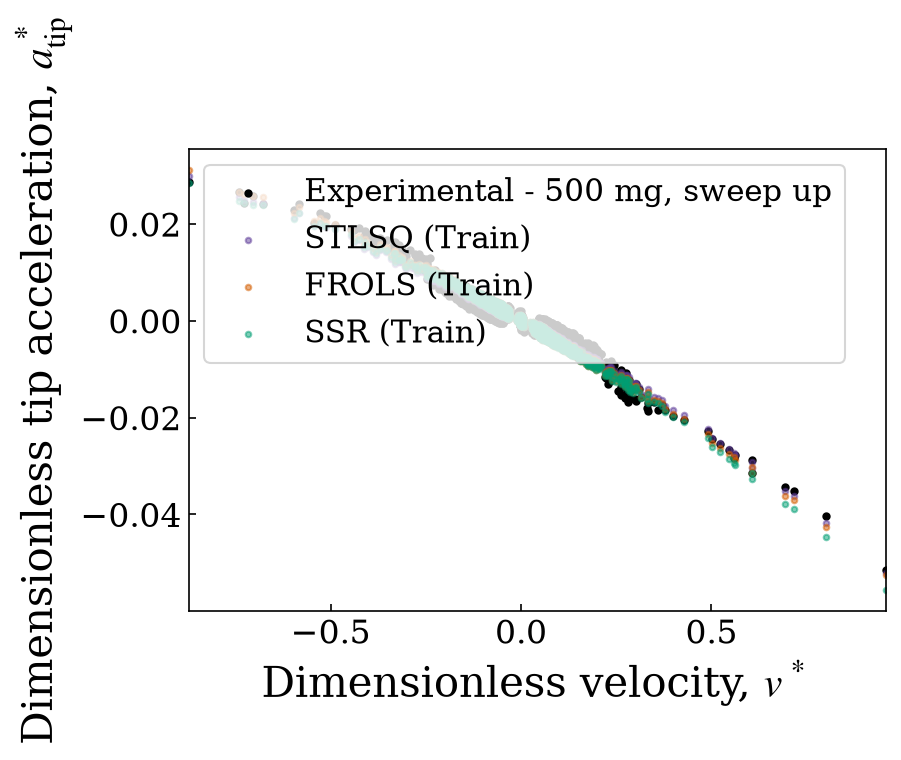

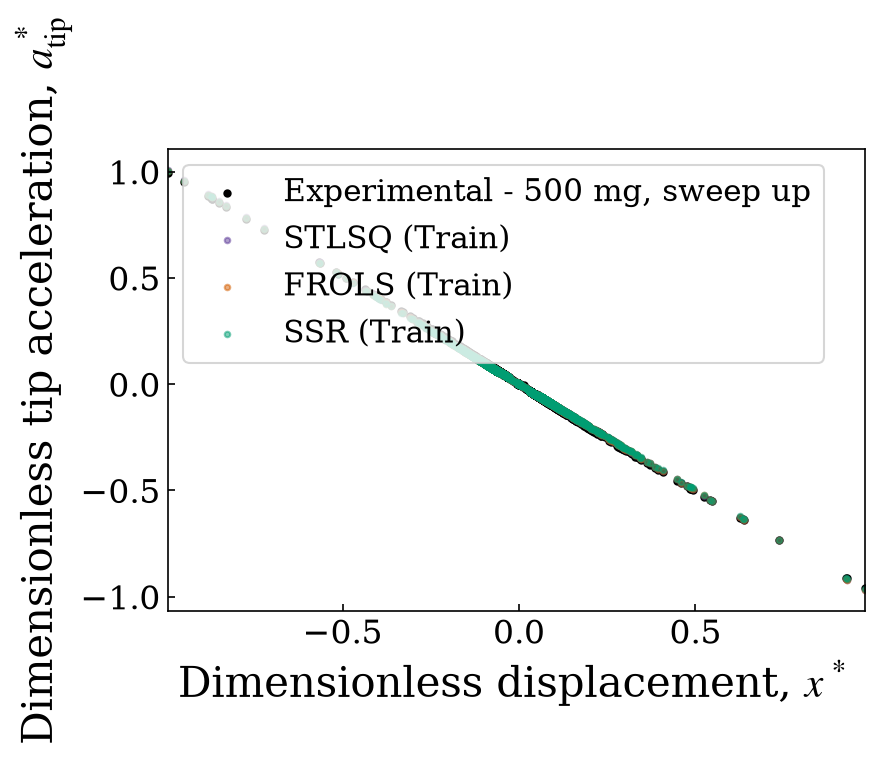

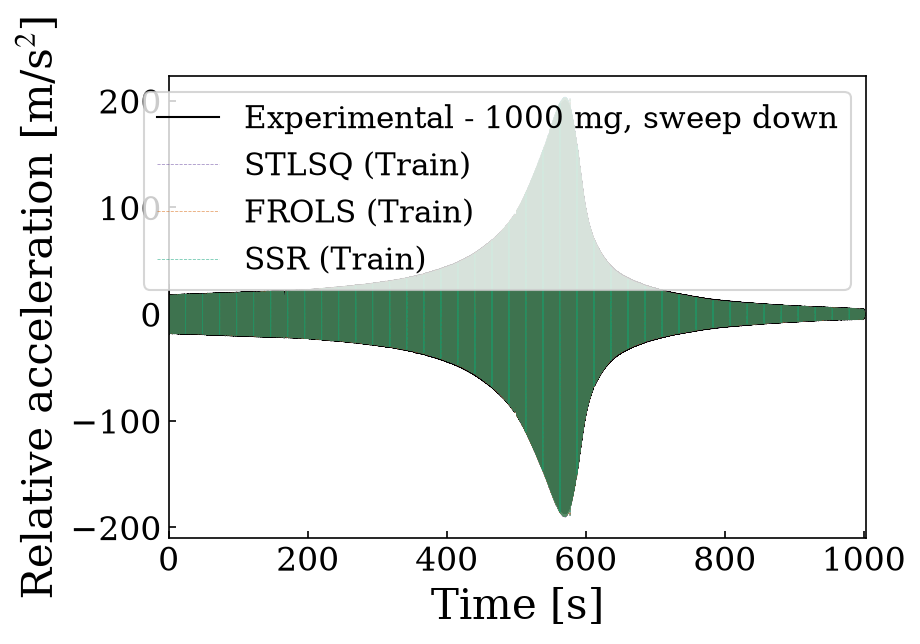

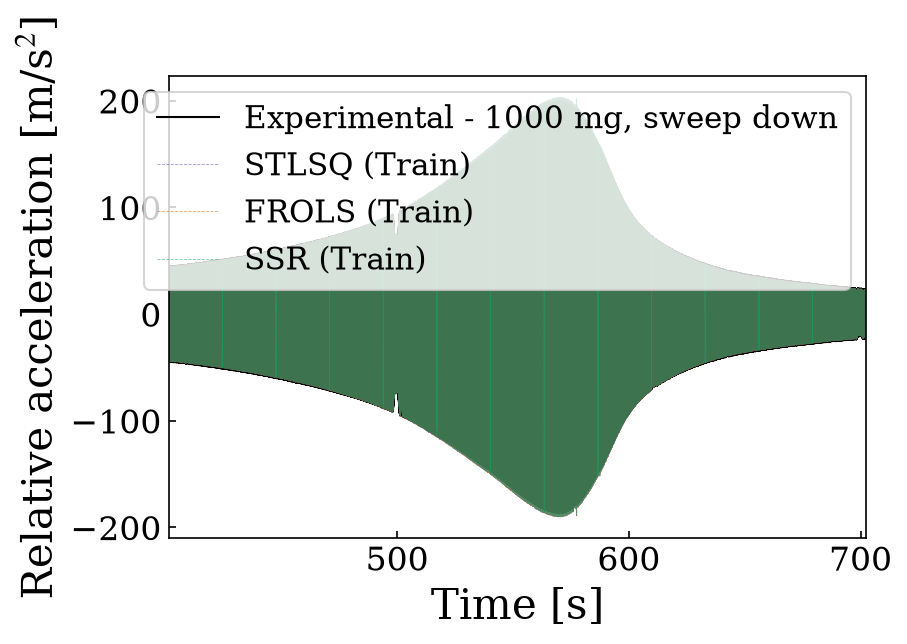

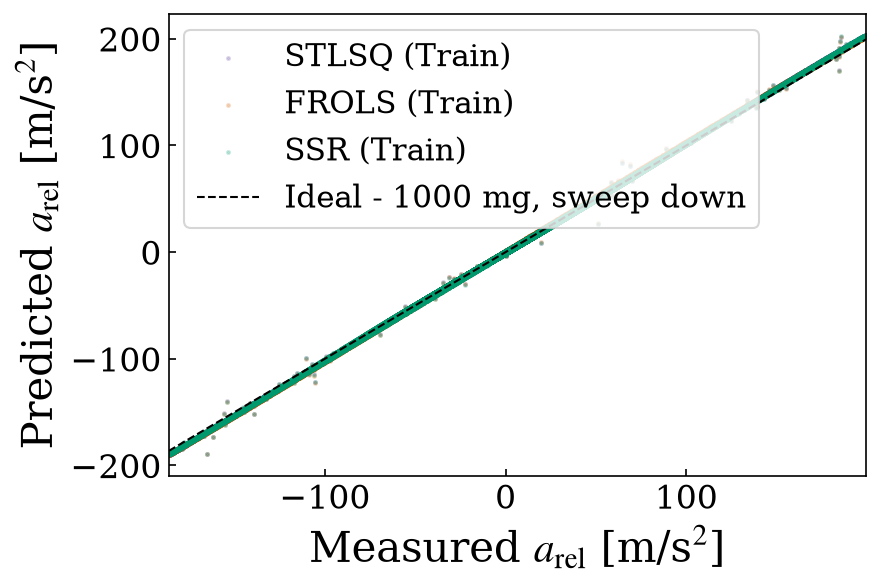

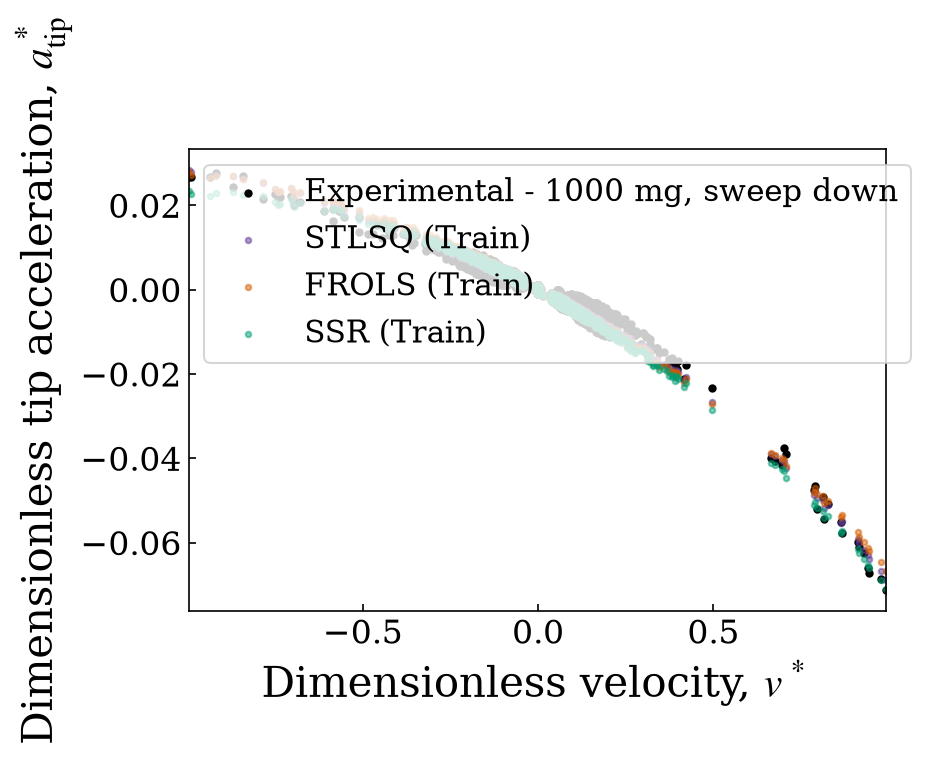

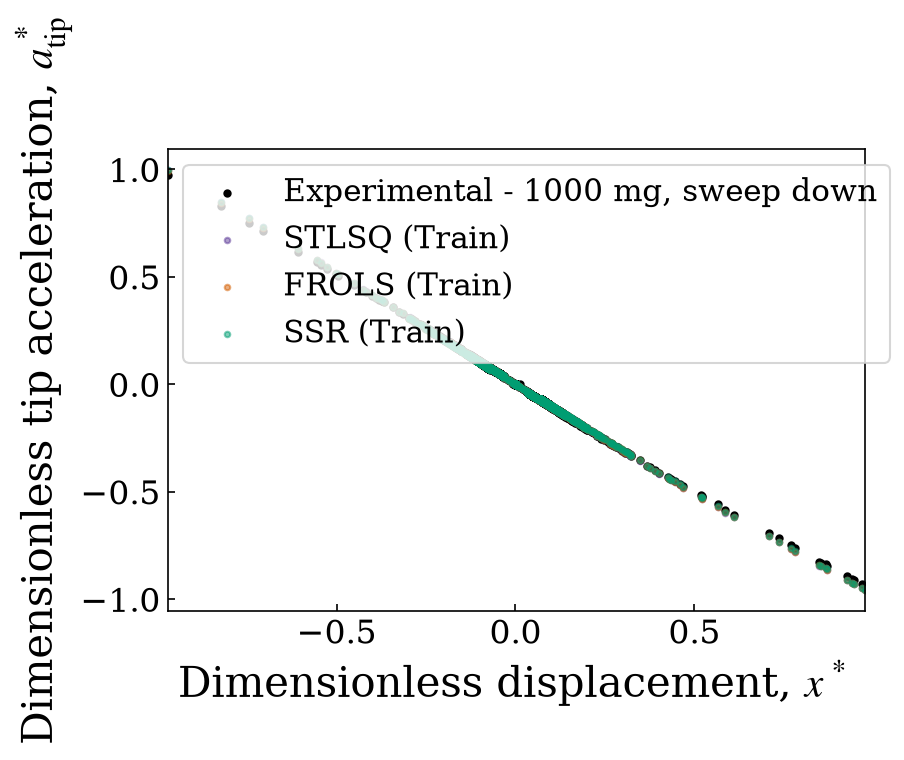

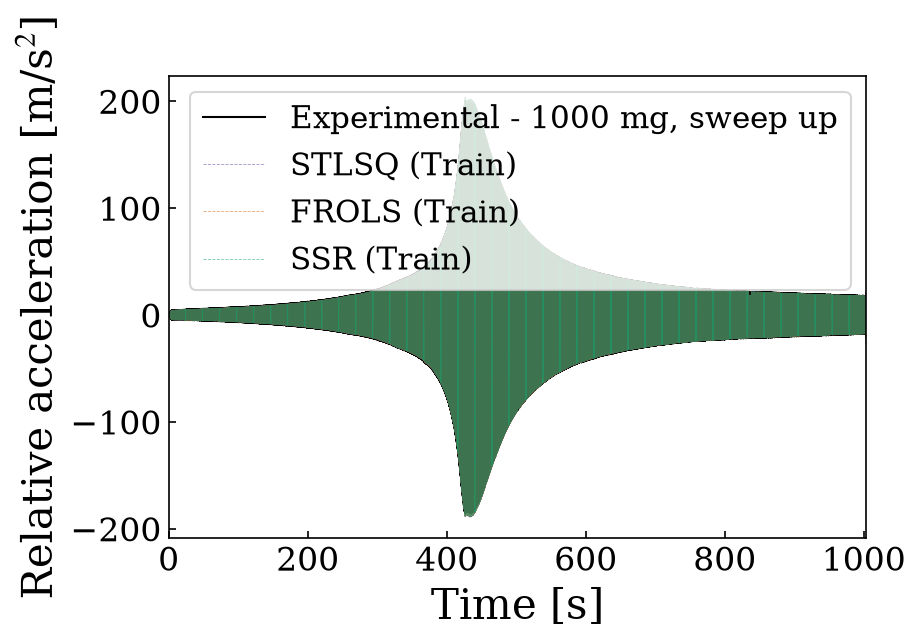

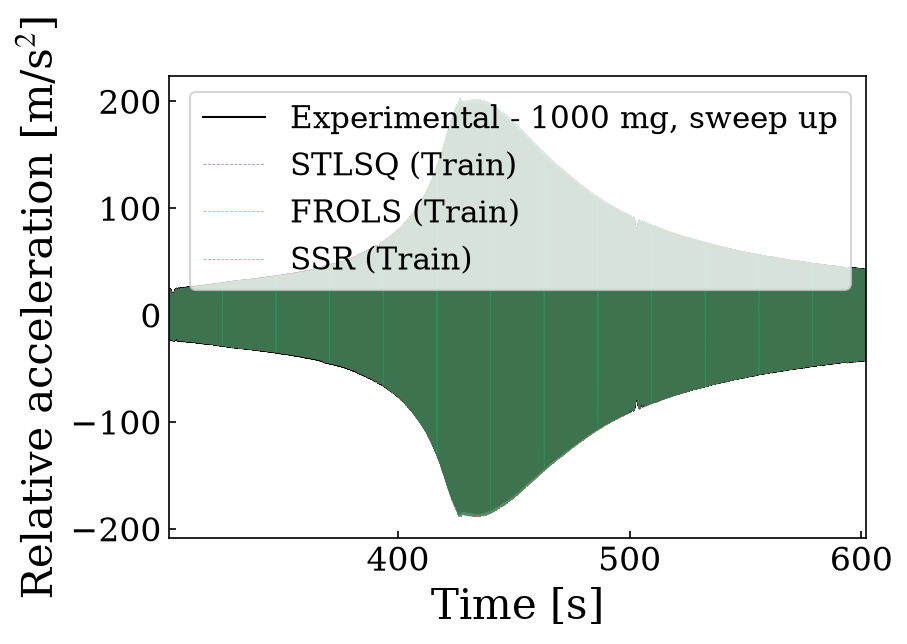

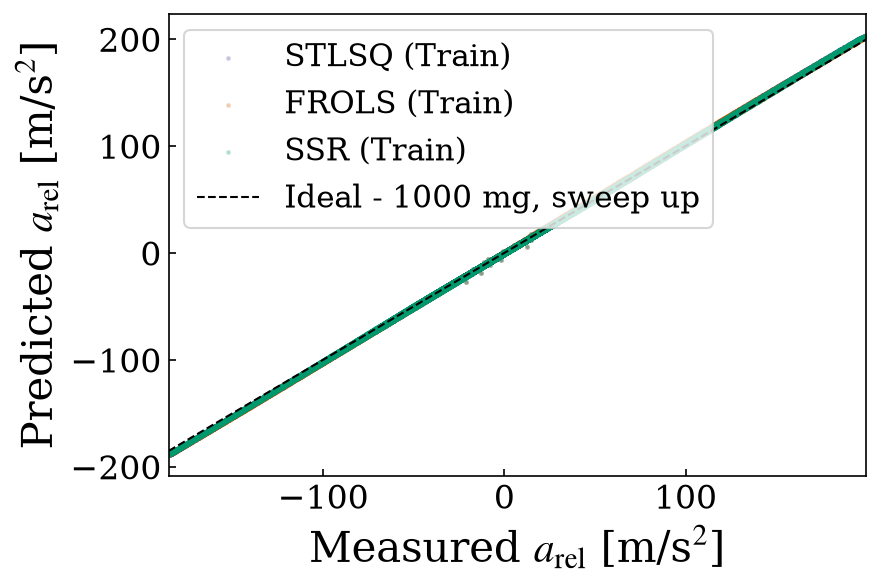

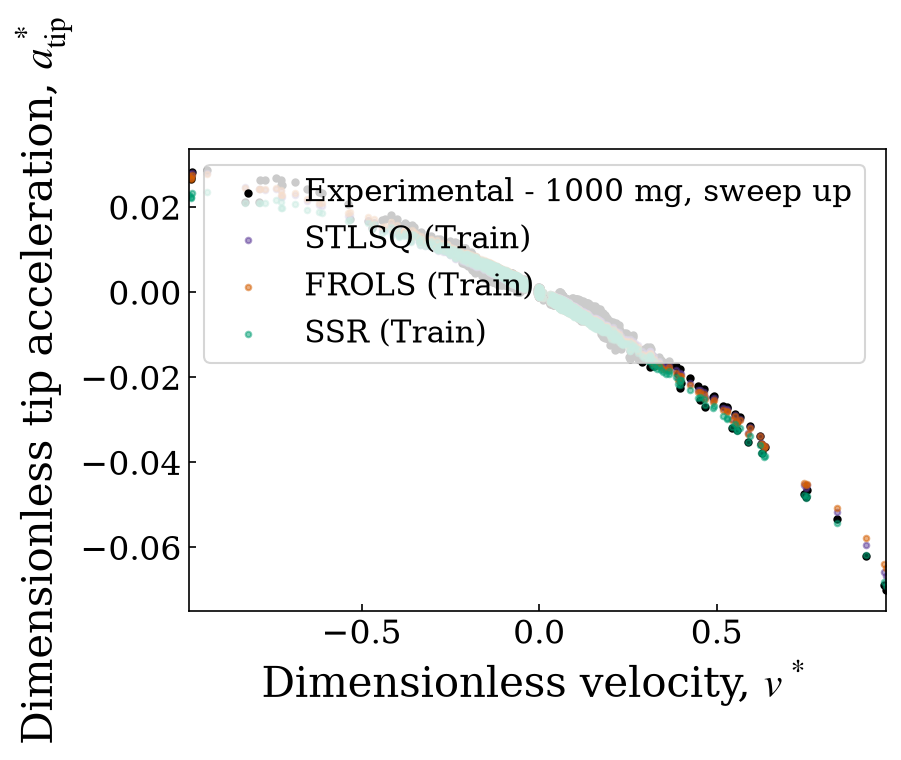

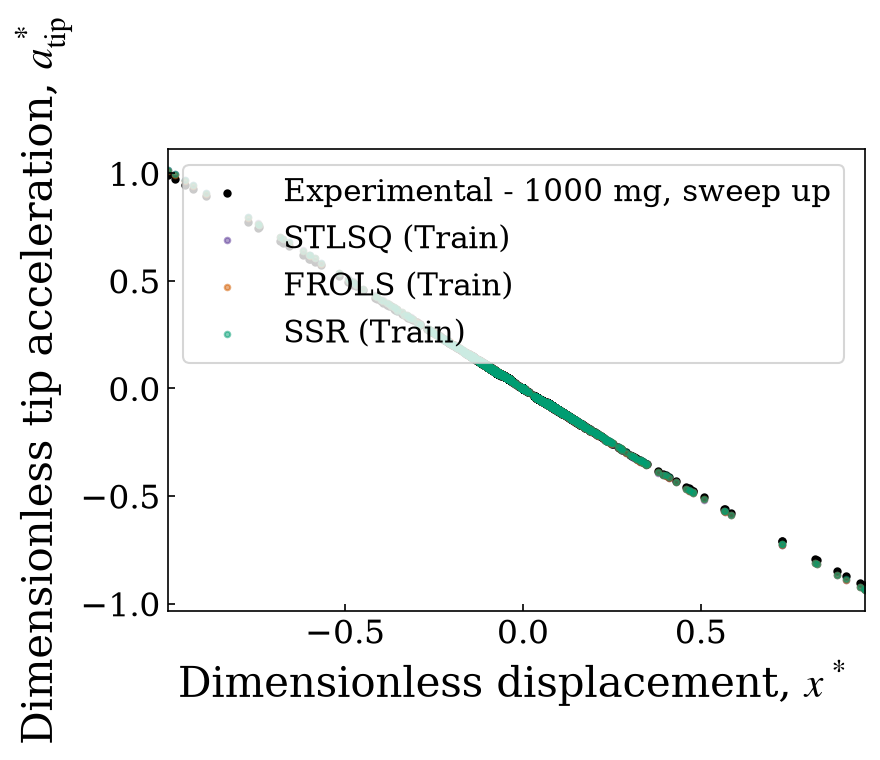

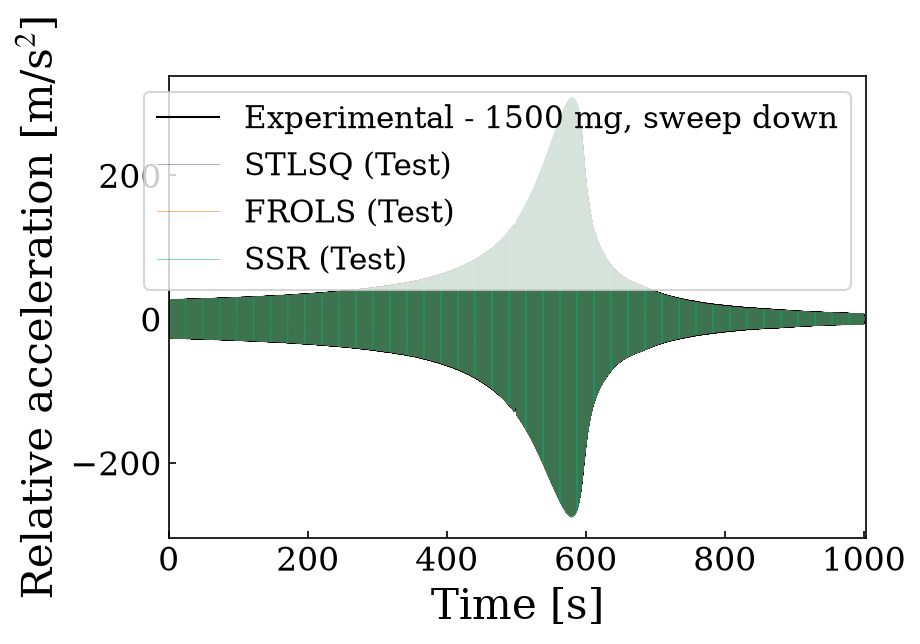

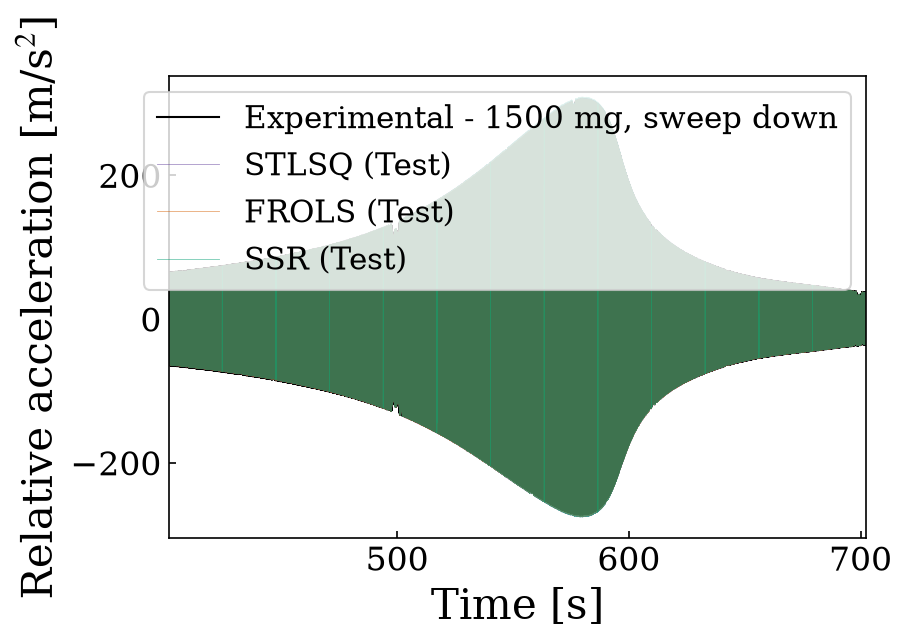

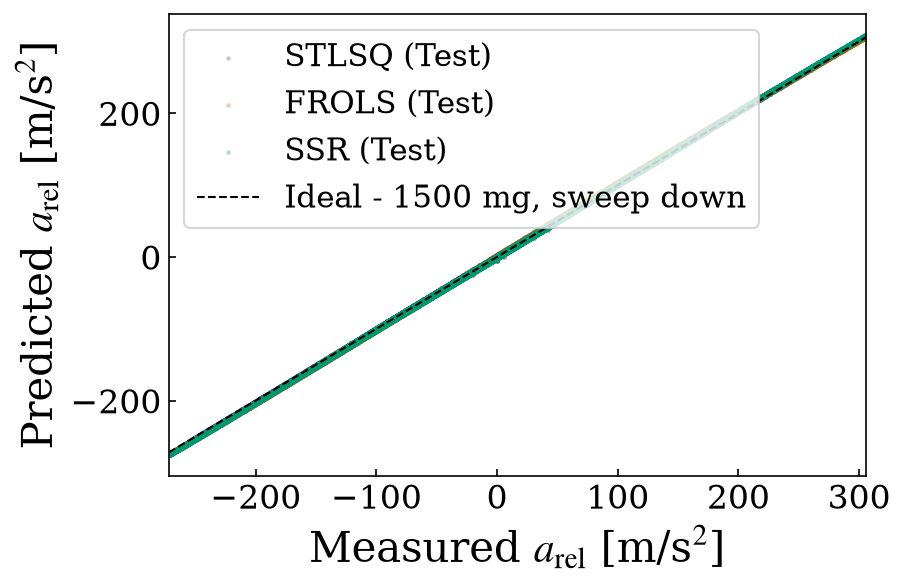

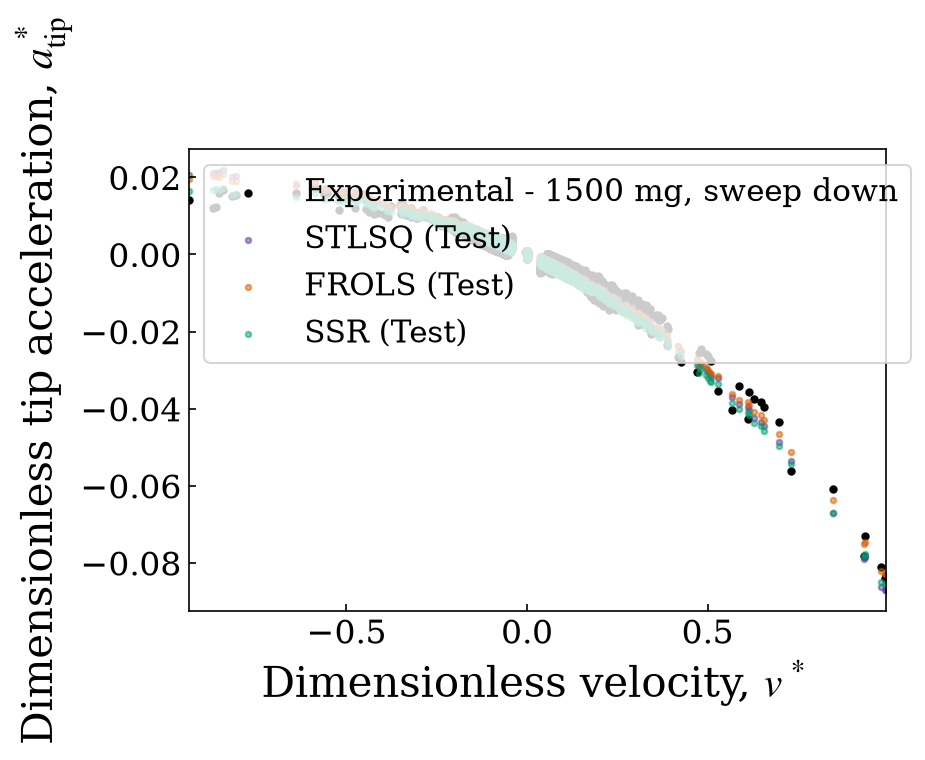

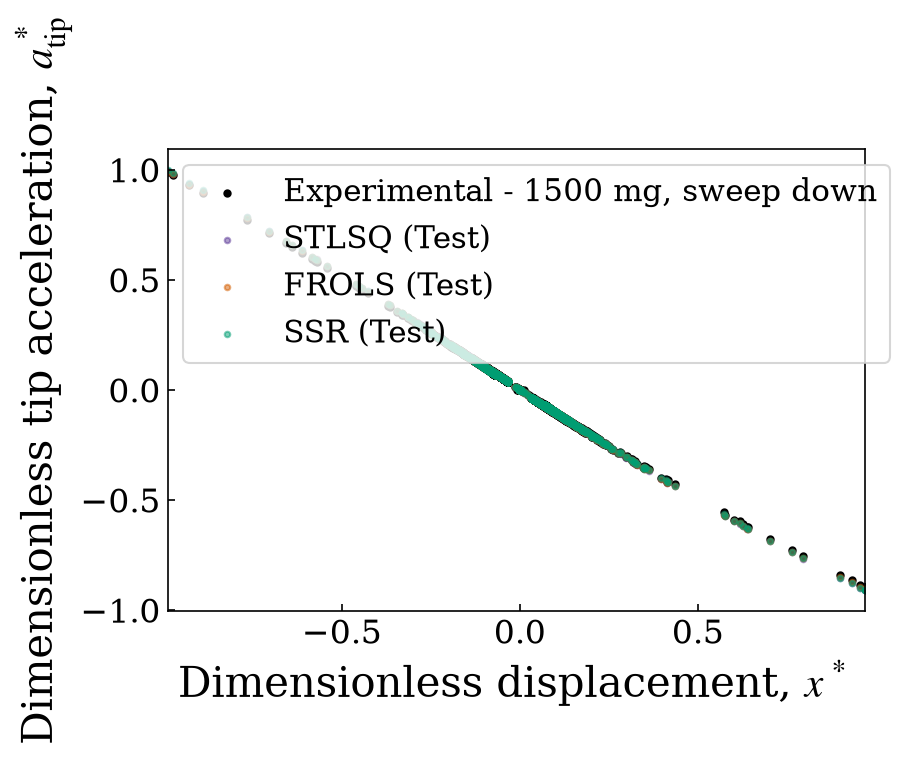

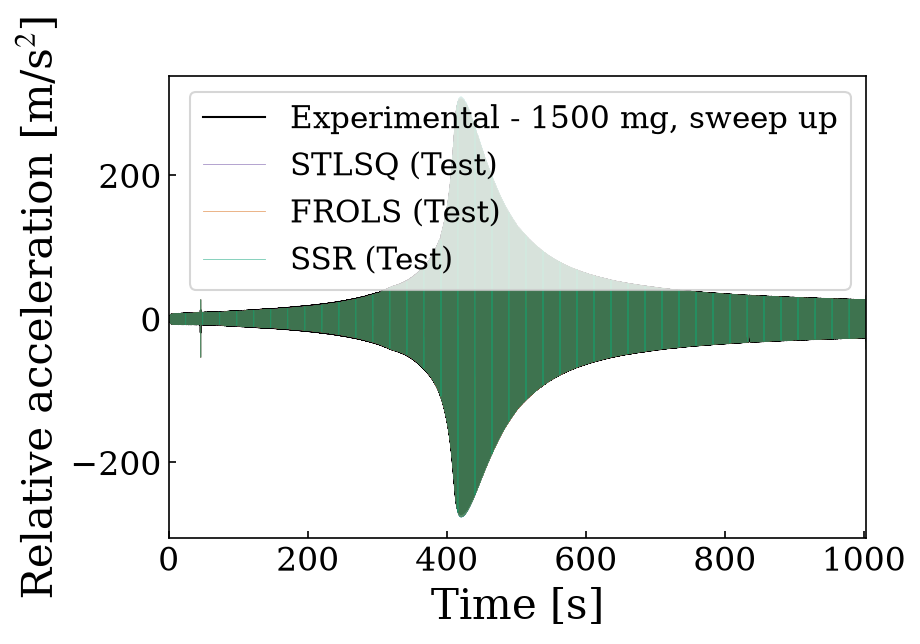

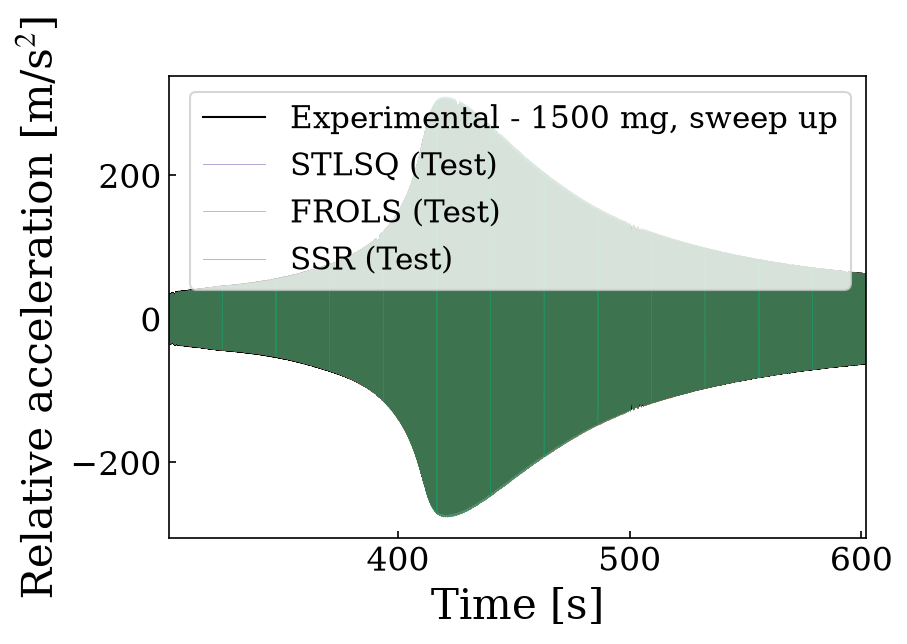

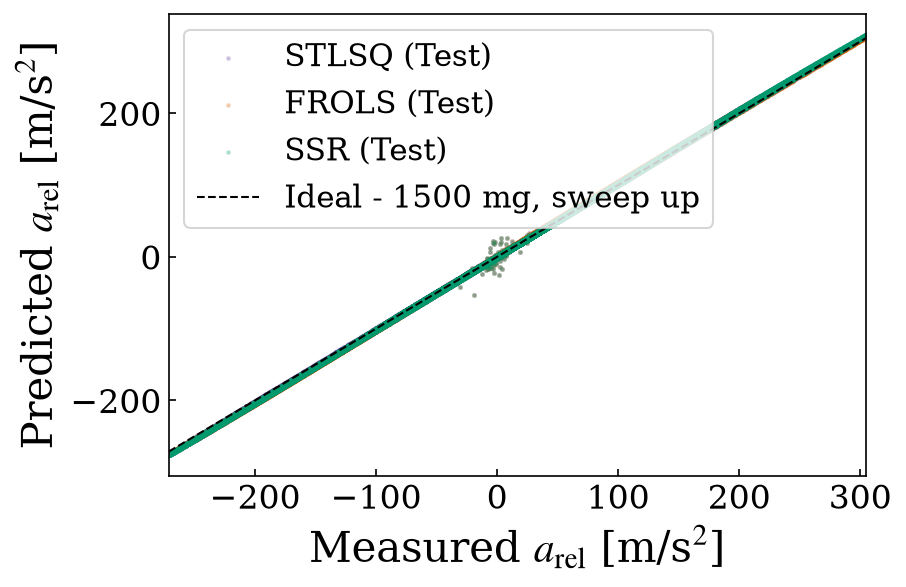

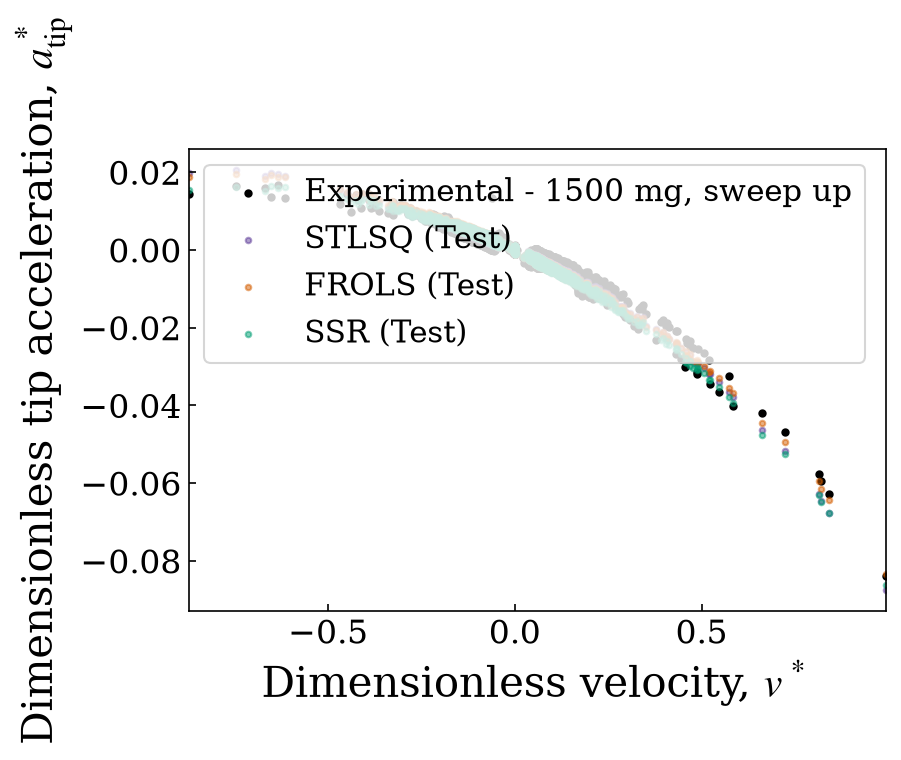

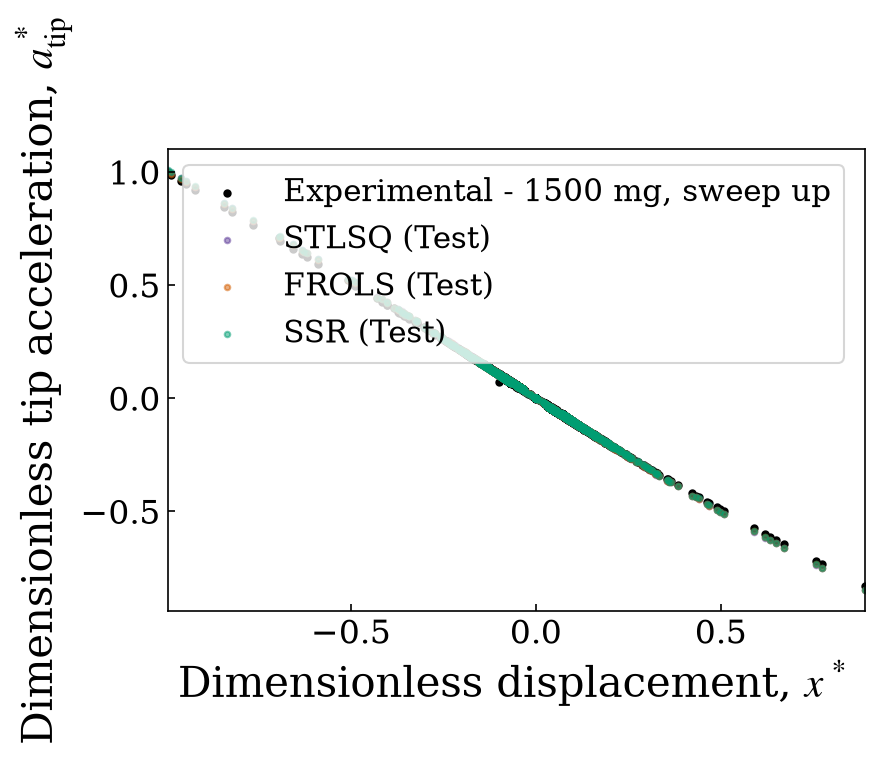

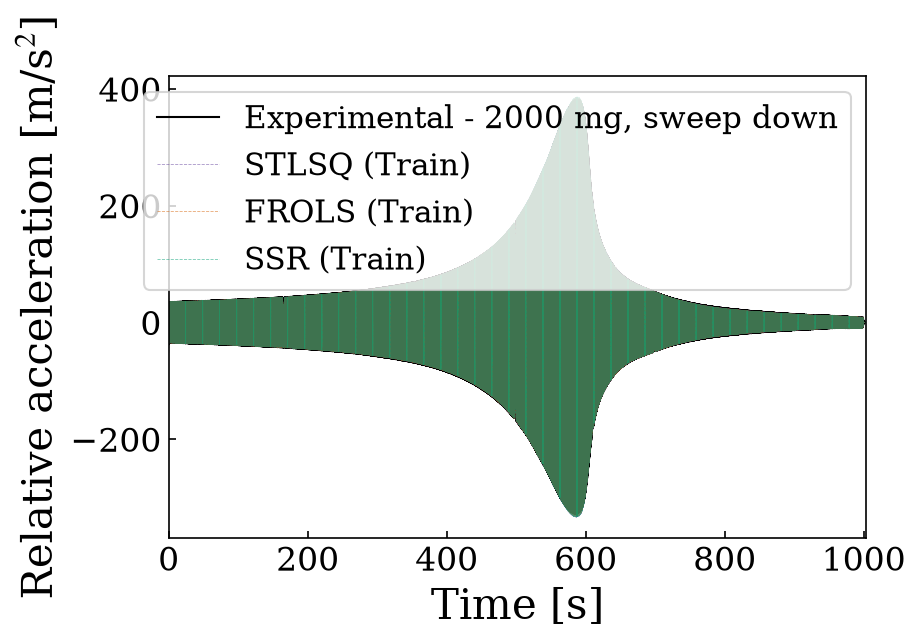

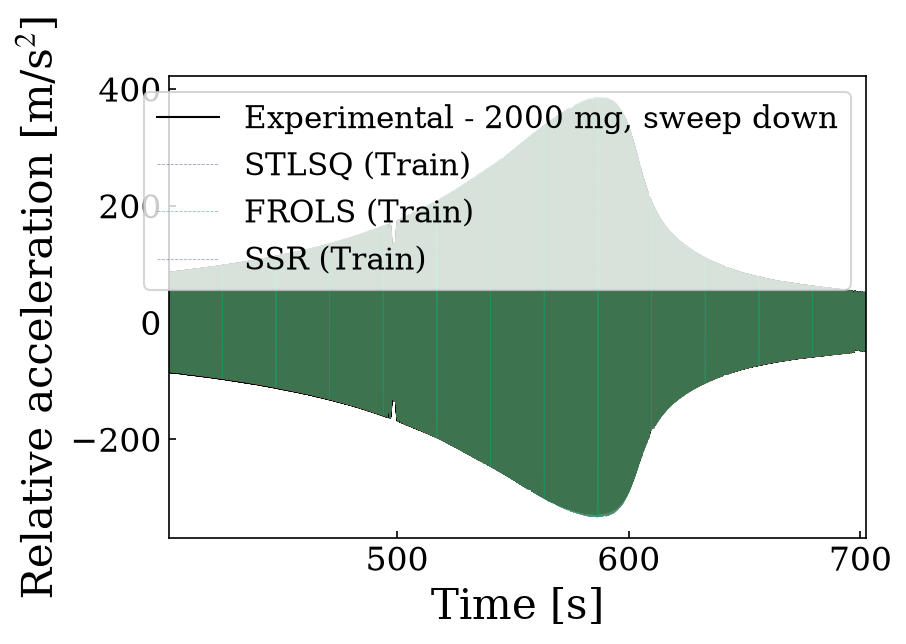

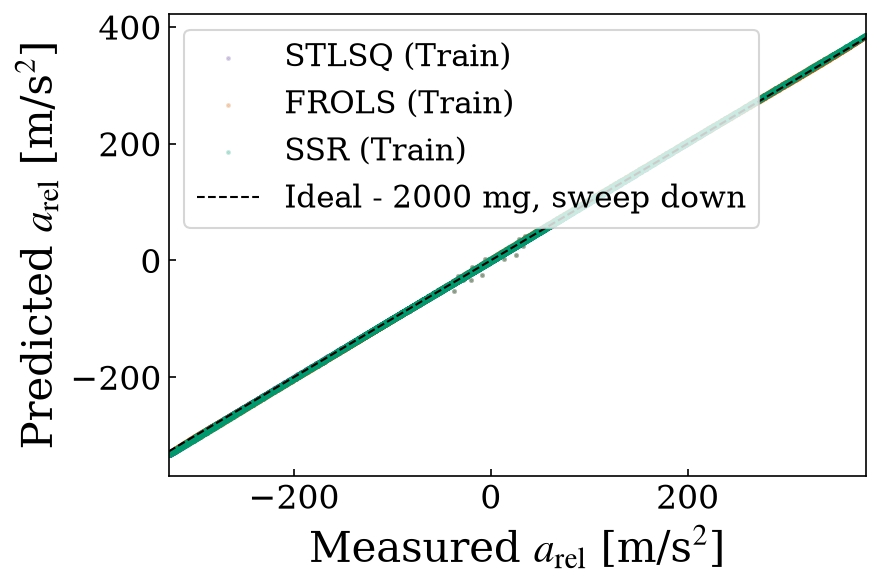

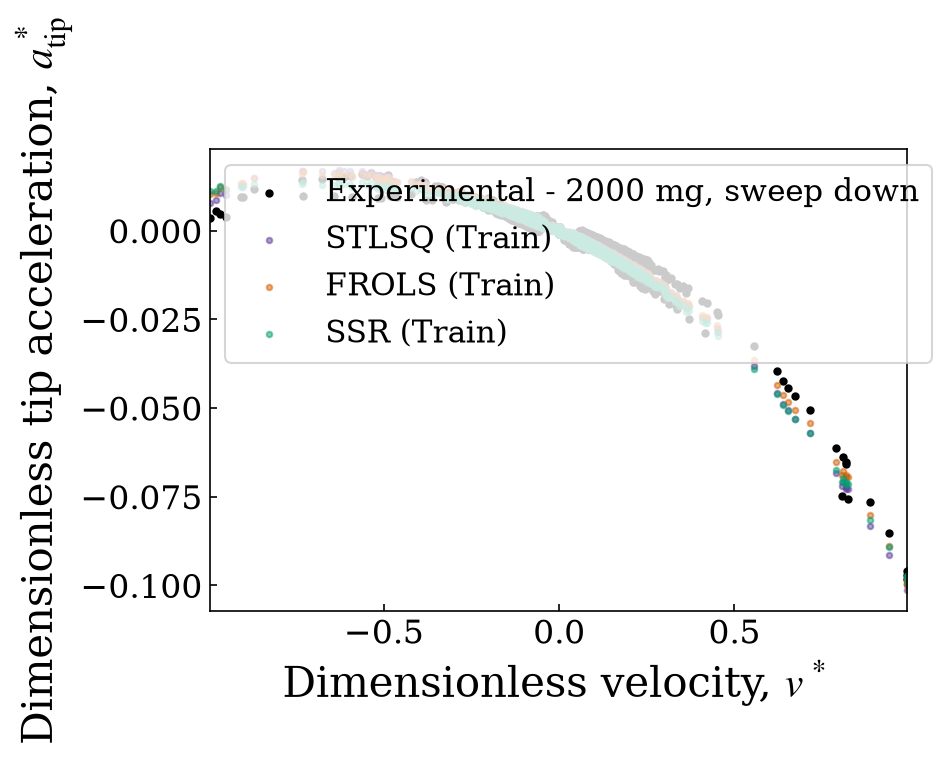

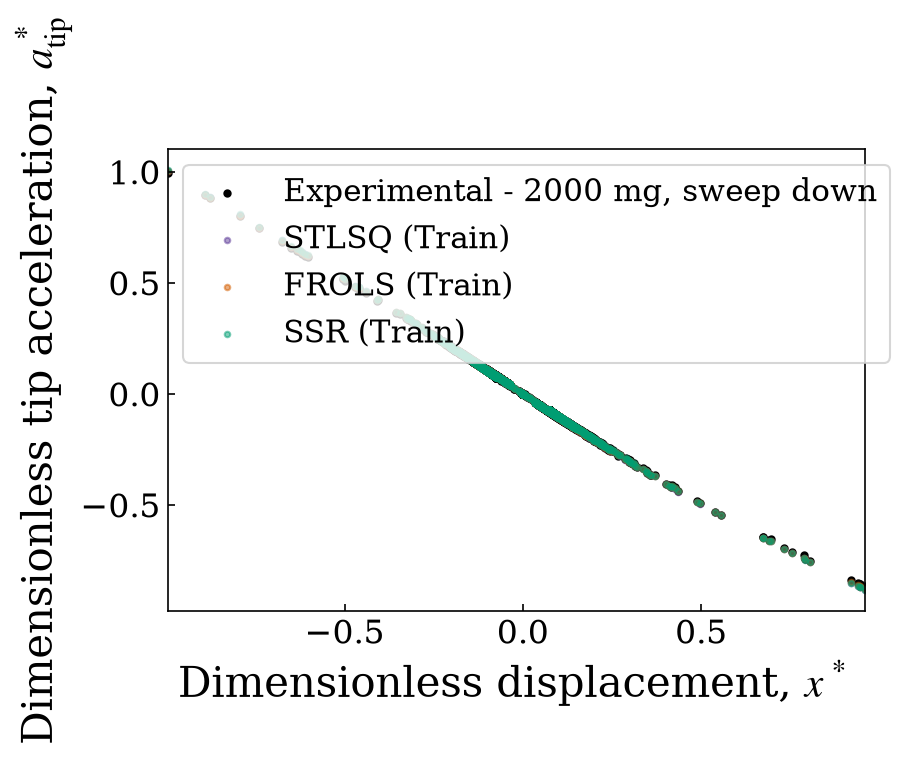

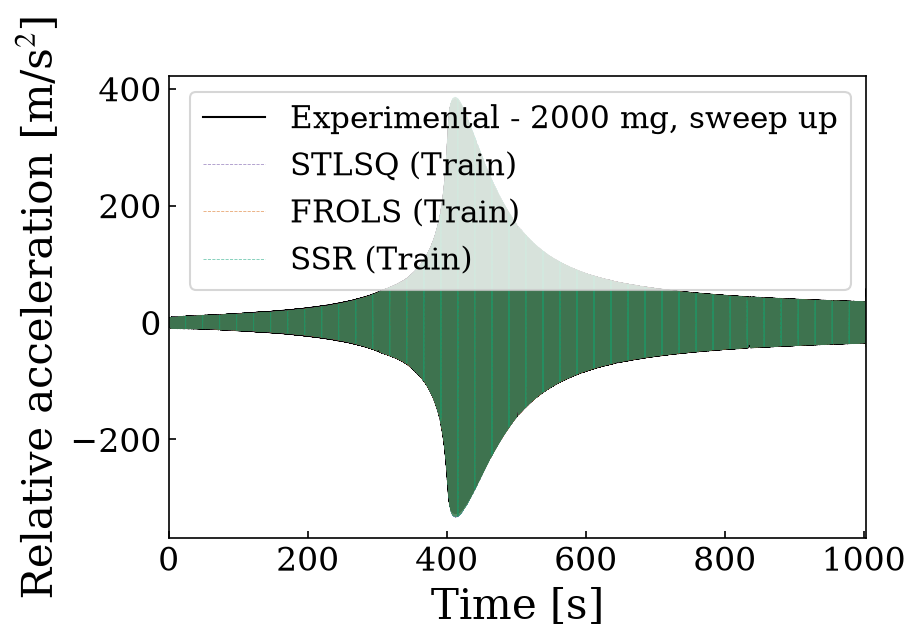

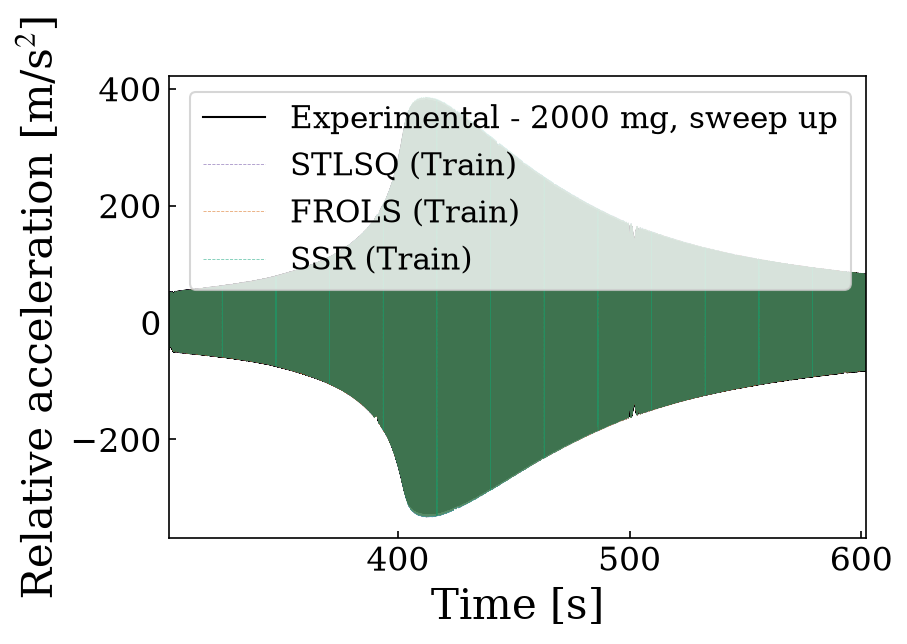

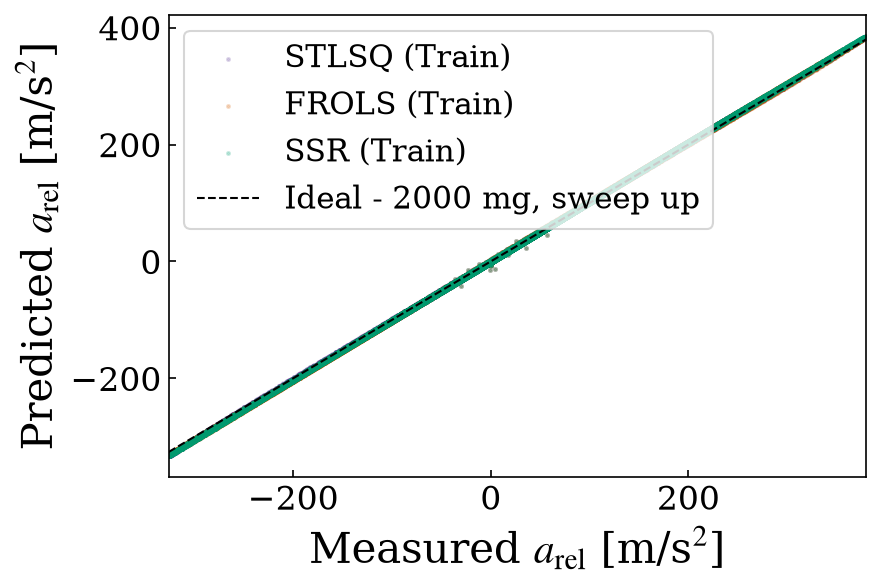

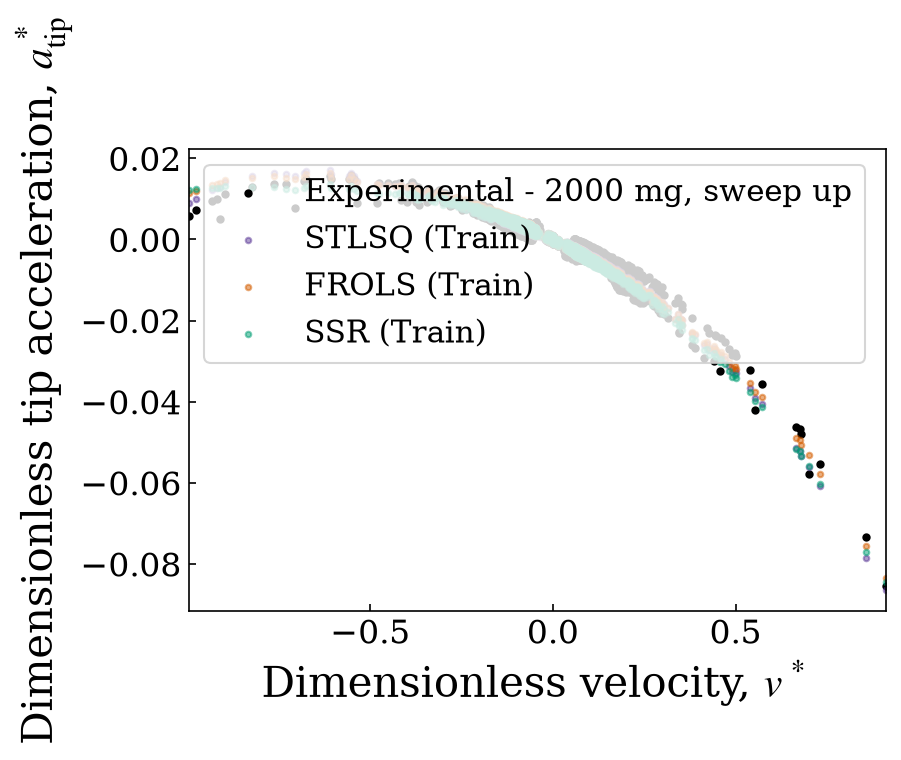

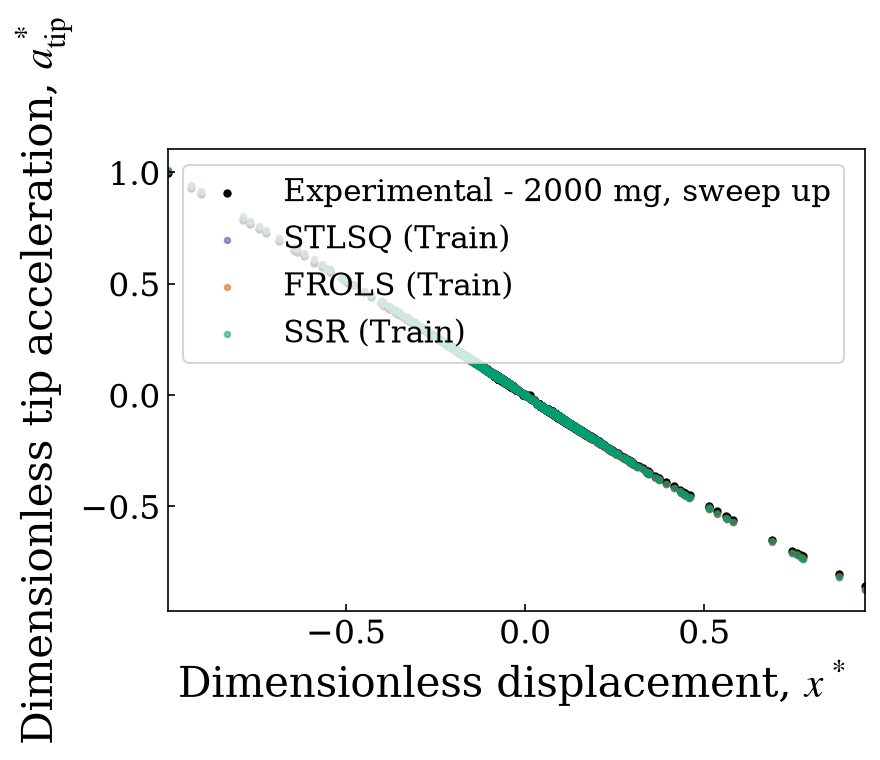

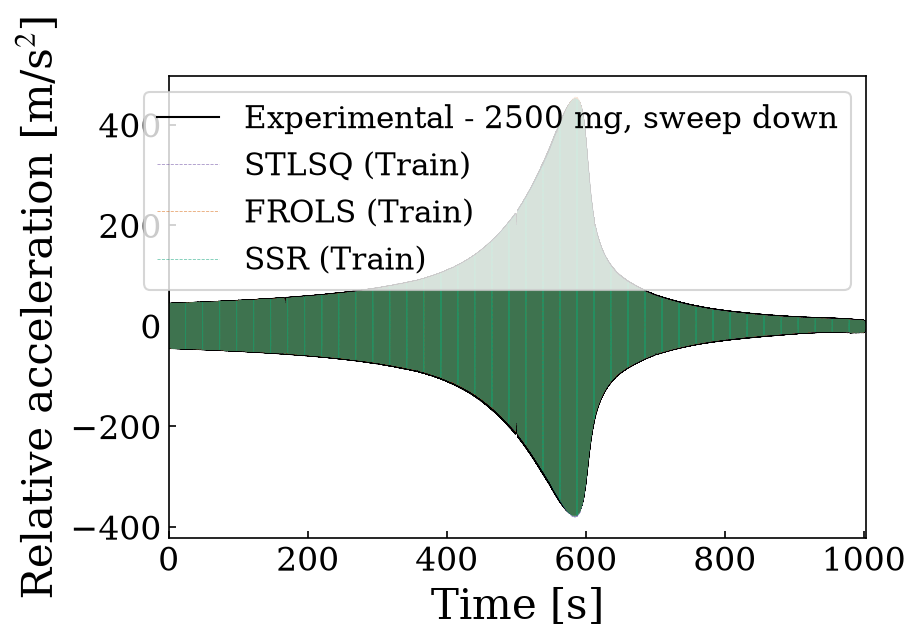

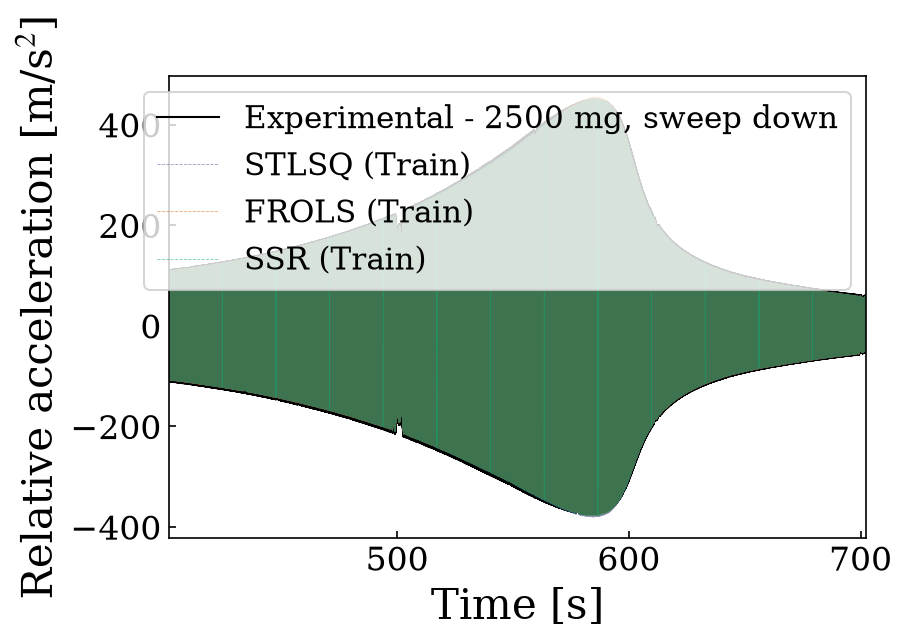

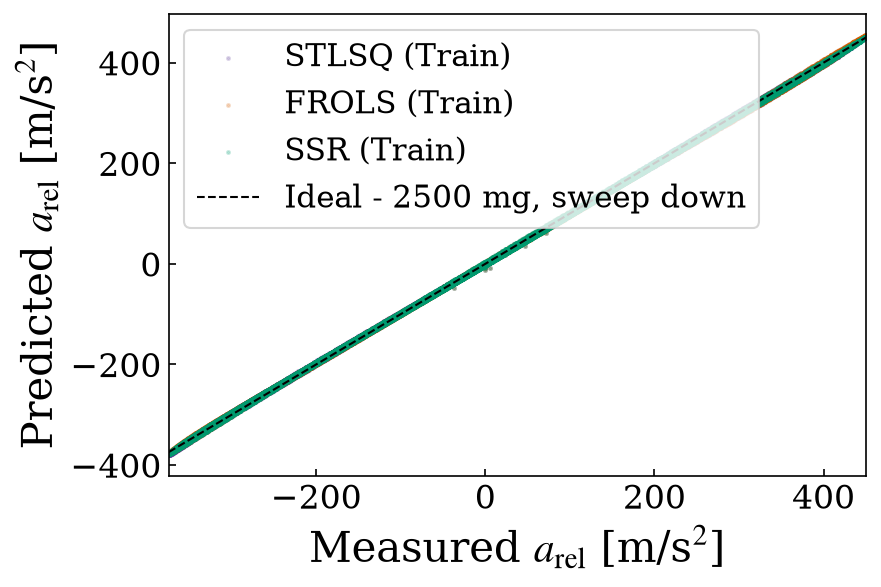

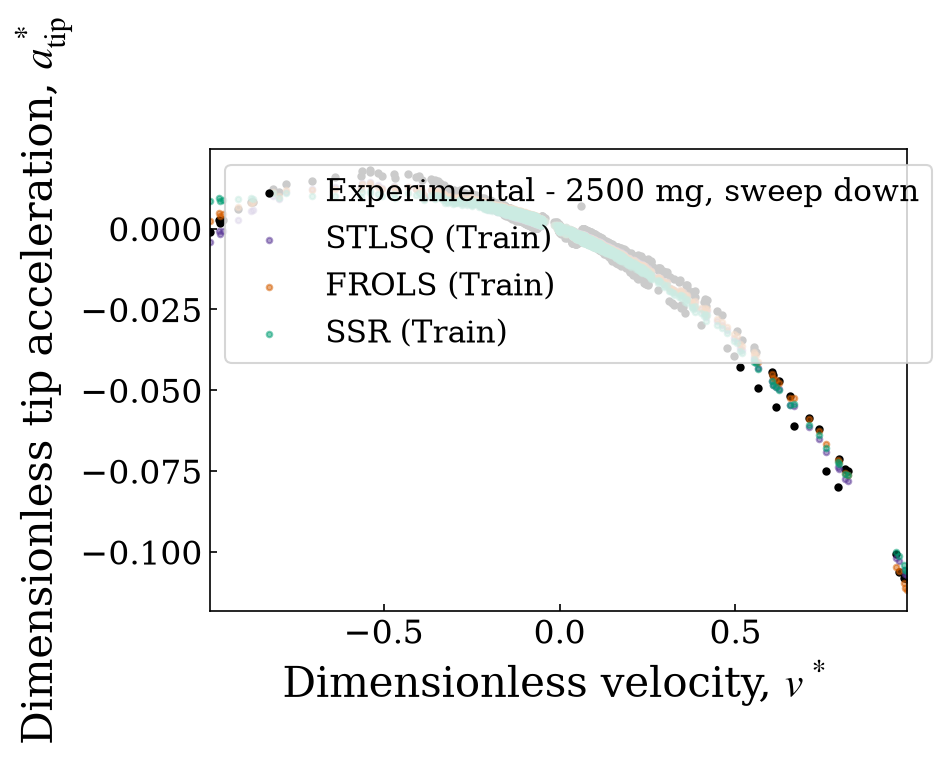

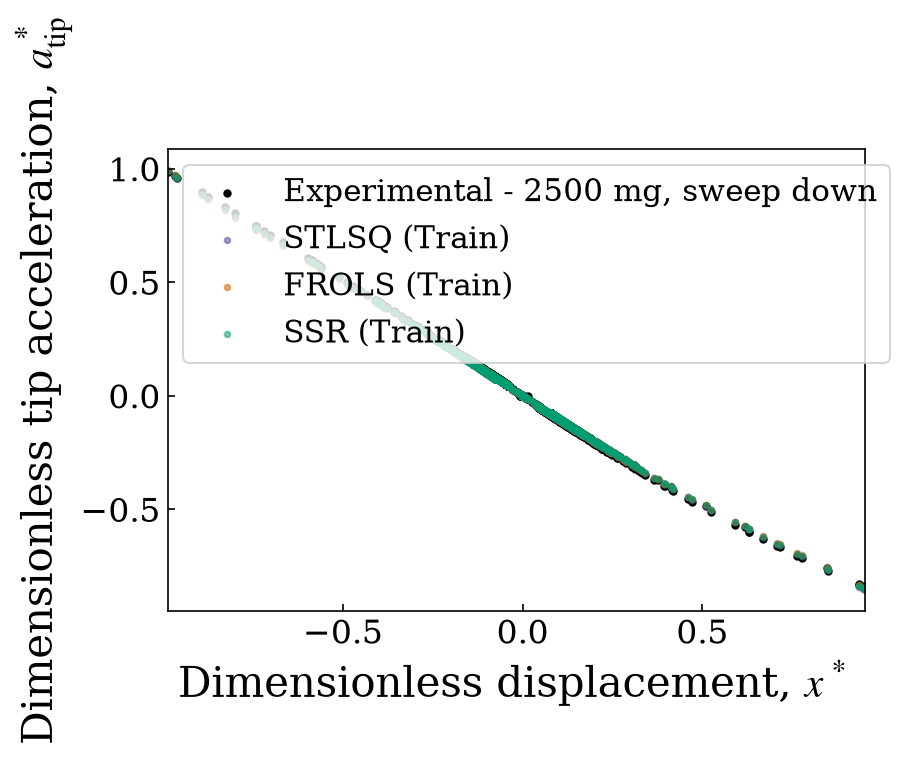

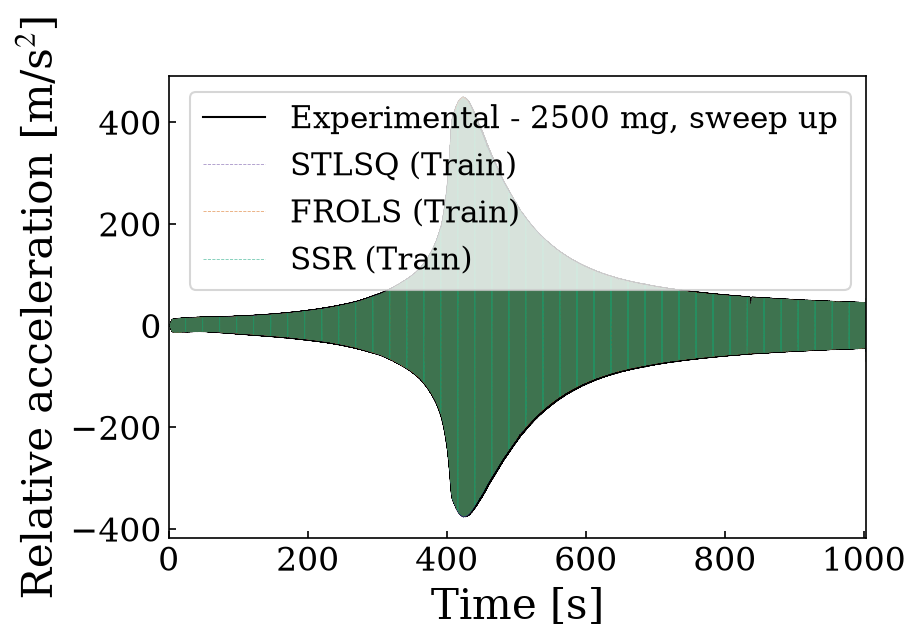

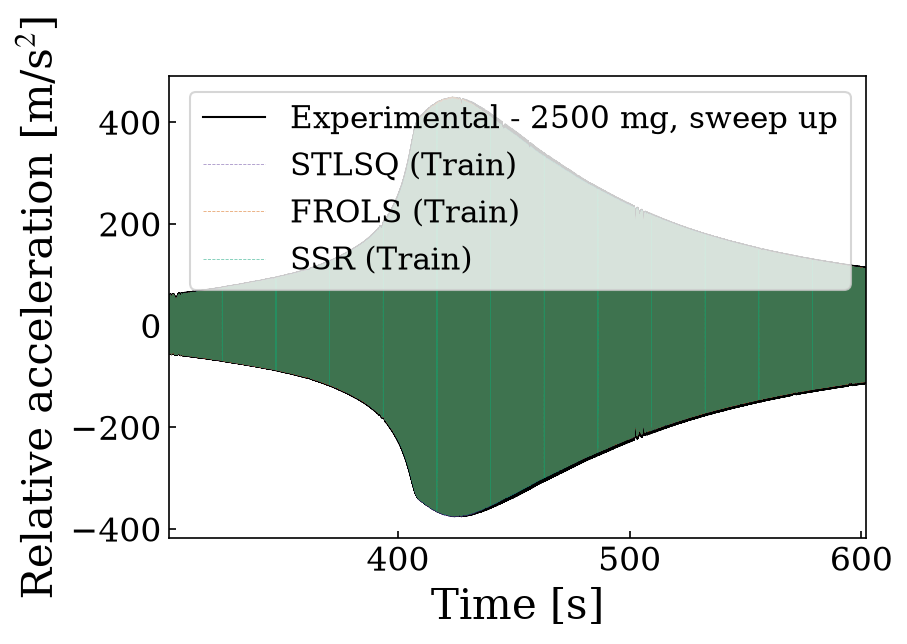

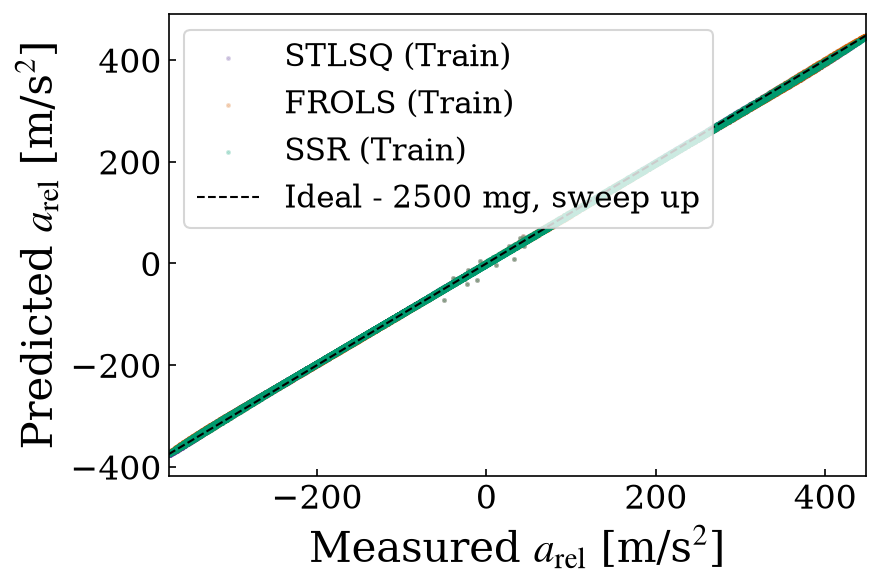

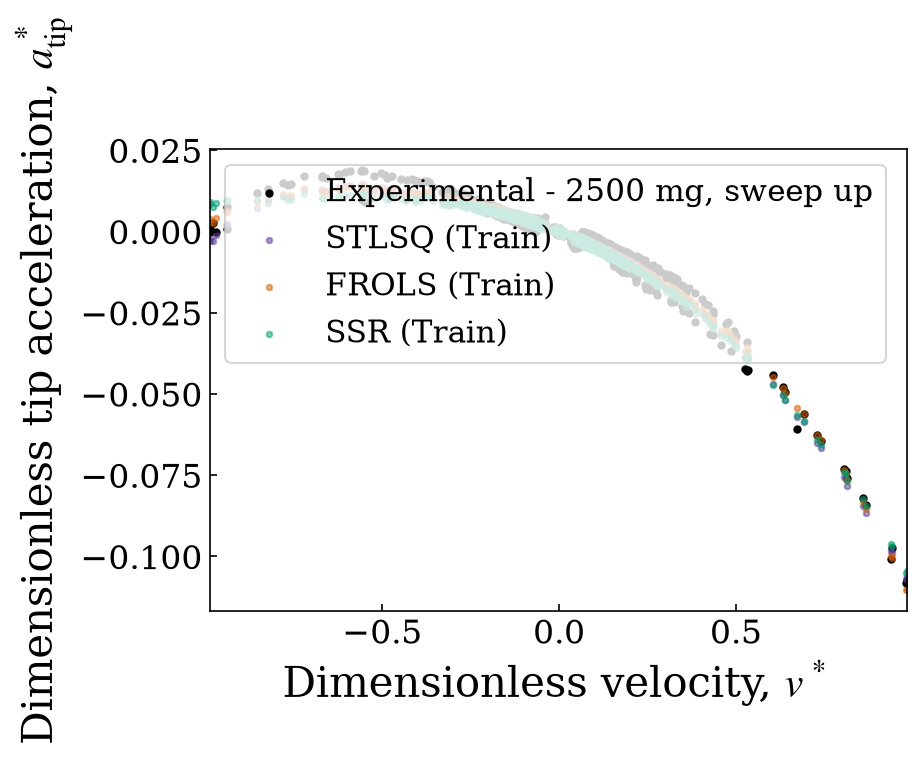

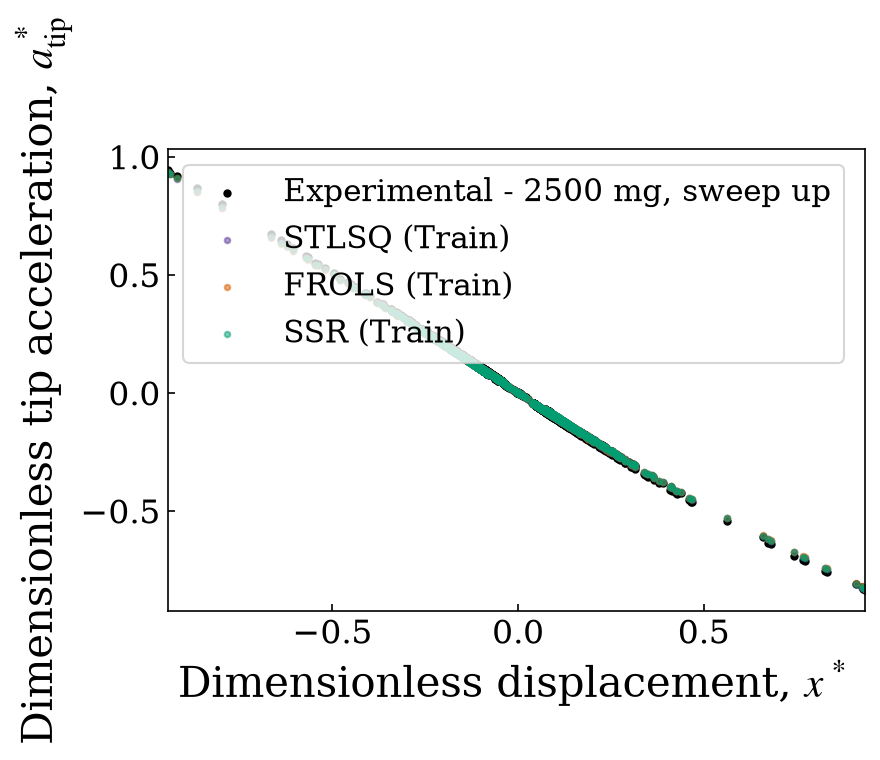

In [22]:
dimensionless_scales = plot_diagnostics(one_step_series, FIGURES_DIR)

## Save results

In [23]:
def model_record(theta):
    return {
        "equations": ["v", equation_text(theta, precision=16)],
        "coefficients": theta.copy(),
        "polynomial_powers": POWERS.copy(),
        "library_feature_names": FEATURE_NAMES,
        "active_acceleration_terms": count_active(theta),
        "active_polynomial_terms": active_polynomial_terms(theta),
        "physical_diagnostics": physical_diagnostics(theta),
    }


configuration = {
    "levels_mg": LEVELS_MG,
    "protocol": PROTOCOL_DESCRIPTION,
    "regression_step": 1,
    "polynomial_degrees": POLYNOMIAL_DEGREES,
    "stlsq_threshold_fractions": STLSQ_THRESHOLD_FRACTIONS, "stlsq_alpha": STLSQ_ALPHA, "stlsq_max_iter": STLSQ_MAX_ITER,
    "library_scaling": "columns scaled to unit RMS; STLSQ threshold = fraction of the training target std",
    "frols_max_terms": FROLS_MAX_TERMS, "frols_alpha": FROLS_ALPHA,
    "ssr_max_iter": SSR_MAX_ITER, "ssr_alphas": SSR_ALPHAS, "ssr_criterion": SSR_CRITERION,
    "coefficient_tolerance": COEFFICIENT_TOLERANCE,
    "acceptable_error_increase": ACCEPTABLE_ERROR_INCREASE,
    "sweep_min_hz": SWEEP_MIN_HZ, "sweep_max_hz": SWEEP_MAX_HZ, "resonance_band_hz": RESONANCE_BAND_HZ,
    "total_error_weight": TOTAL_ERROR_WEIGHT, "resonance_error_weight": RESONANCE_ERROR_WEIGHT,
    "plot_window_s": None,
    "selected_polynomial_degree": BEST_DEGREE,
    "selected_stlsq_threshold_fraction": SELECTED_STLSQ_THRESHOLD_FRACTION,
    "selected_frols_max_terms": SELECTED_FROLS_MAX_TERMS,
    "selected_ssr_alpha": SELECTED_SSR_ALPHA,
    "selected_ssr_history_index": SELECTED_SSR_HISTORY_INDEX,
    "evaluation_mode": "measured-state acceleration",
    "selection_mode": "common criterion: smallest model within ACCEPTABLE_ERROR_INCREASE of the best training "
                      "score (0.3 pooled NRMSE + 0.7 pooled resonance NRMSE) on the training levels; physical checks: "
                      "restoring force, damping, input term",
    "fit_representation": "full regression rows of every experiment; all samples used, no compression",
}
pysindy_results = {
    "schema_version": 5,
    "source_prepared_file": str(PREPARED_FILE.resolve()),
    "configuration": configuration,
    "protocol": {"levels_mg": LEVELS_MG, "test_level_mg": TEST_LEVEL_MG, "training_levels_mg": TRAINING_LEVELS_MG,
                 "split": split_summary, "roles": ROLES, "description": PROTOCOL_DESCRIPTION},
    "signal_names": [s["name"] for s in all_signals],
    "models": {name: model_record(theta) for name, theta in final_models.items()},
    "selection_summary": selection_summary,
    "identification_studies": {
        "polynomial_degree": identification_run["degree_results"], "stlsq": identification_run["stlsq_results"],
        "frols": identification_run["frols_results"], "ssr": identification_run["ssr_results"],
        "training_samples": identification_run["training_samples"],
    },
    "one_step": {"per_signal_metrics": one_step_comparison, "per_level": one_step_per_level,
                 "aggregate_metrics": one_step_aggregate, "series": one_step_series},
    "dimensionless_scales": dimensionless_scales,
}
results_file = RESULTS_DIR / "pysindy_results.pkl"
with results_file.open("wb") as file:
    pickle.dump(pysindy_results, file, protocol=pickle.HIGHEST_PROTOCOL)
print("Saved:", results_file)

Saved: C:\Users\bruno\Downloads\BEPE (2)\BEPE\results\pysindy_results.pkl
